# SHAP + Network Analysis

## Purpose: 
{TODO}


## Packages, Options and Class Instantiation

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

%load_ext autoreload 
%autoreload 2

    
import importlib

SHAP_analysis_class = getattr(
    importlib.import_module("1_shap_network_analyzer"), 
    "ShapNetworkInvestigator"
)


data_modes = ["All-Data", "Unique-Binding"]
binding_modes = ["Bound-Only", "NOT-Bound-Only"]
FDR_cutoffs = [0.1, 0.05]

investigator = SHAP_analysis_class()
investigator.hash_metadata

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Data QC</h1>

## Check for Nulls in `SHAP`/Binding

In [ ]:
investigator.run_data_quality_assertions()

## Assert `SHAP` additivity


In [ ]:
investigator.assert_SHAP_additivity()

## Check no `Local SHAP` variance per binding pattern

In [ ]:
table = investigator.check_no_SHAP_variance_per_binding_pattern()

table.sample(10)
table["num_unique_shap_rows"].value_counts()

## Create Final SHAP Cache

In [ ]:
investigator.load_final_SHAP_data(underlying_data="All-Data")

In [ ]:
for key in investigator.final_all_data_SHAP_data: 
    investigator.final_all_data_SHAP_data[key].shape
    investigator.final_all_data_SHAP_data[key].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Predicted vs Actual Plots</h1>

In [ ]:
for mode in data_modes:

    investigator.plot_actual_vs_predicted_for_best_models(underlying_data = mode)

In [ ]:
investigator.plot_actual_vs_predicted_for_best_models(underlying_data = "Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">View Feature Distribution of Local SHAP</h1>

In [ ]:
# investigator.plot_local_SHAP_distribution_per_feature_as_mp4()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP Across Models and for Average Local SHAP</h1>

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.plot_global_SHAP_mean_vs_variance(mode="5_dfs", binding_unique="Unique-Binding")

for key in tables: 
    key 
    tables[key].head()


In [ ]:
investigator.plot_global_SHAP_coefficient_of_variation(mode='5_dfs', binding_unique="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Variance Analysis</h1>

In [ ]:
investigator.plot_SHAP_CV()

In [ ]:
investigator.plot_SHAP_std()

In [ ]:
investigator.plot_local_SHAP_mean_vs_variance()

In [ ]:
for mode in binding_modes: 
    mode
    investigator.calculate_local_SHAP_mean_vs_variance_deciles(mode=mode)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">ElasticNet</h1>


In [ ]:
elasticnet = investigator.load_elasticnet_coefficients()

for key in elasticnet: 
    key 
    elasticnet[key]["coefficients"].head()

In [ ]:
investigator.plot_elasticnet_coefficients()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Position 3 + 4 Significance in Global SHAP/ElasticNet</h1>


In [ ]:
investigator.check_position_3_and_4_significance_for_global_SHAP_and_elasticnet()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Is Position 3/4 Activator-Like and Other Positions Repressor-Like?

In [ ]:
investigator.is_position_3_4_activating_and_others_repressing()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Make Global SHAP Plots with Variations</h1>

# Variations: 
* Unique Binding Patterns 
* Feature is bound
* Feature is NOT bound
* Feature is NOT bound in CONTROL
* Feature is NOT bound in ROW W/ RBP KD AT ANY POSITION
* Feature is NOT bound in ROW W/ RBP KD AT SPECIFIC POSITION
* Use signed (not absolute value) summation of Local SHAP
* `Log-Odds` signed summation of Bound Only Local SHAP

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_between_unique_binding_and_all_data()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_specialized_vs_regular_global_SHAP(underlying_data="Unique-Binding")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="CTRL")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-CTRL", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD_at_position")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD_at_position", binding_unique="All-Data")

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    tables = investigator.calculate_specialized_global_SHAP(mode=mode, condition=None, underlying_data="Unique-Binding")
    for key in tables: 
        tables[key]

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    investigator.plot_global_SHAP(mode=mode, binding_unique="Unique-Binding")

In [ ]:
investigator.compare_bound_global_SHAP_and_signed_mean_bound_local_SHAP()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", condition=None, underlying_data="Unique-Binding")

for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.compare_signed_mean_bound_local_SHAP_between_probability_and_log_odds_units()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP across Binding Modes & Positional Vignettes


In [ ]:
investigator.plot_global_SHAP_distributions_across_binding_modes()

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode = "Bound-Only", underlying_data="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode="Signed-Local-SHAP-Mean-Bound-Only", underlying_data="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Sign Analysis</h1>

# Includes: 


* Percentage of local SHAP that is non-zero at different cutoffs
* Percentage of local SHAP positive/negative either when feature is bound or unbound
* Understanding activation and repression through custom metric

## % Non-Zero SHAP

In [ ]:
investigator.calculate_local_SHAP_percent_non_zero(mode="Unique-Binding").head()

In [ ]:
investigator.plot_local_SHAP_percent_non_zero()

## Negative & Positive Local SHAP

In [ ]:
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "NOT-Bound-Only", underlying_data="Unique-Binding")
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "Bound-Only", underlying_data="Unique-Binding")


In [ ]:
investigator.plot_percent_positive_and_negative_local_SHAP_per_feature(underlying_data="Unique-Binding")

## Custom Metric for Activation and Repression Behavioral Understanding

In [ ]:
for binding_mode in ["Bound-Only", "NOT-Bound-Only"]: 
    investigator.calculate_activator_repressor_behavior_score(binding_mode=binding_mode, underlying_data="Unique-Binding").head()

In [ ]:
investigator.plot_activator_repressor_behavior_score(underlying_data = "Unique-Binding")

In [ ]:
investigator.plot_activator_repressor_behavior_score_vs_percent_positive_and_negative(underlying_data="Unique-Binding")

<h1 style="color: red; font-weight: bold; font-size: 60px;">INCOMPLETE</h1>

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP for Zero Binding Rows</h1>

Looks at: 

* Heatmap of `NOT Bound` "`Global SHAP`" for rows of: 
    * Control
    * The KD of the RBP for that feature
    * That feature having in-silico knockdown 

<br>


* Heatmap of % of zero binding events that have "0" `Local SHAP`

<br>

In [ ]:
investigator.shap_for_zero_binding_features_by_condition()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential Splicing Events</h1>

### Focuses on: 

* RBP-specific: 
    * \# Significant Diff Events 
    * \# Significant Diff Events w/ RBP KD at **ANY** Position
* Feature-specific: 
    * \# Significant Diff Events w/ RBP KD at **SPECIFIC** Position

<br>

* `Fisher's Exact` test for association between binding and significant splicing


In [ ]:
investigator.create_feature_metric_summary_table()

In [ ]:
investigator.plot_differential_splicing_types()


In [ ]:
investigator.plot_differential_ranks()

In [ ]:
investigator.plot_differential_ratios()

In [ ]:
investigator.plot_matching_differential_ratios_scatterplot()

In [ ]:
for cutoff in FDR_cutoffs: 
    investigator.binding_vs_diff_events_fishers_association(FDR_threshold = cutoff)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Metric w/ Regulatory Explanation</h1>

* `Global SHAP`
* `ElasticNet coefficients`
* `Total Binding`
* `# Differential Events`

In [ ]:
investigator.plot_feature_metric_summary_table()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Hacky, Quick, and Dirty Analysis</h1>

In [ ]:
investigator.hacky_not_bound_global_SHAP_by_number_binding()

In [ ]:
investigator.hacky_plot_bound_unbound_signed_local_SHAP_vs_PSI()

In [ ]:
investigator.hacky_plot_bound_unbound_all_data_vs_unique_binding_global_SHAP()

In [ ]:
investigator.hacky_explore_SHAP_in_PSI_units()

In [ ]:
investigator.hacky_check_shap_additivity()

In [ ]:
investigator.hacky_log_odds_test_data_dpsi_vs_local_shap_scatterplot()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Binding Sum Distribution</h1>

In [ ]:
investigator.plot_binding_sum_distribution()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Per Row: Local SHAP Values > Cutoff</h1>

In [ ]:
table = investigator.calculate_num_and_percent_bound_local_shap_greater_than_cutoff()

In [ ]:
table["K562"].head()

In [ ]:
investigator.plot_num_and_percent_bound_local_shap_greater_than_cutoff()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Choose Examples Showcasing Local SHAP and PSI Concordance</h1>


In [ ]:
investigator.plot_local_SHAP_vs_PSI(feature="AQR_4_shap", underlying_data="All-Data")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PSI Distributions by Binding Mode</h1>


In [ ]:
investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding")

In [ ]:
for seed in range(100, 1001, 100): 
    investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding", sampling_seed = seed)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP Waterfall Plot</h1>


In [ ]:
# table = investigator.find_shap_waterfall_plot_examples()

# for key in table: 
    
#     key
#     tmp = table[key]
    
#     tmp.shapeiiiiii
#     pd.DataFrame(tmp["RBP_KD_Target"].sort_values().unique())
    
#     tmp

In [ ]:
investigator.find_shap_waterfall_plot_examples()

In [ ]:
investigator.plot_shap_waterfall_examples()

In [ ]:
investigator.final_all_data_SHAP_data["K562"].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Train, Validate, Test Comparisons</h1>

In [ ]:
investigator.compare_train_validate_test_metrics()

In [ ]:
investigator.TMP["K562"].head()
investigator.TMP["HepG2"].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential PSI and Local SHAP</h1>


# `Test` Data

In [ ]:
for cutoff in [None] + FDR_cutoffs: 
    
    investigator.plot_dpsi_vs_local_SHAP_for_test_data(FDR_threshold = cutoff)

In [ ]:
investigator.correlation_between_test_dpsi_and_local_SHAP()

2025-10-02 19:45:05.181 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:05.294 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

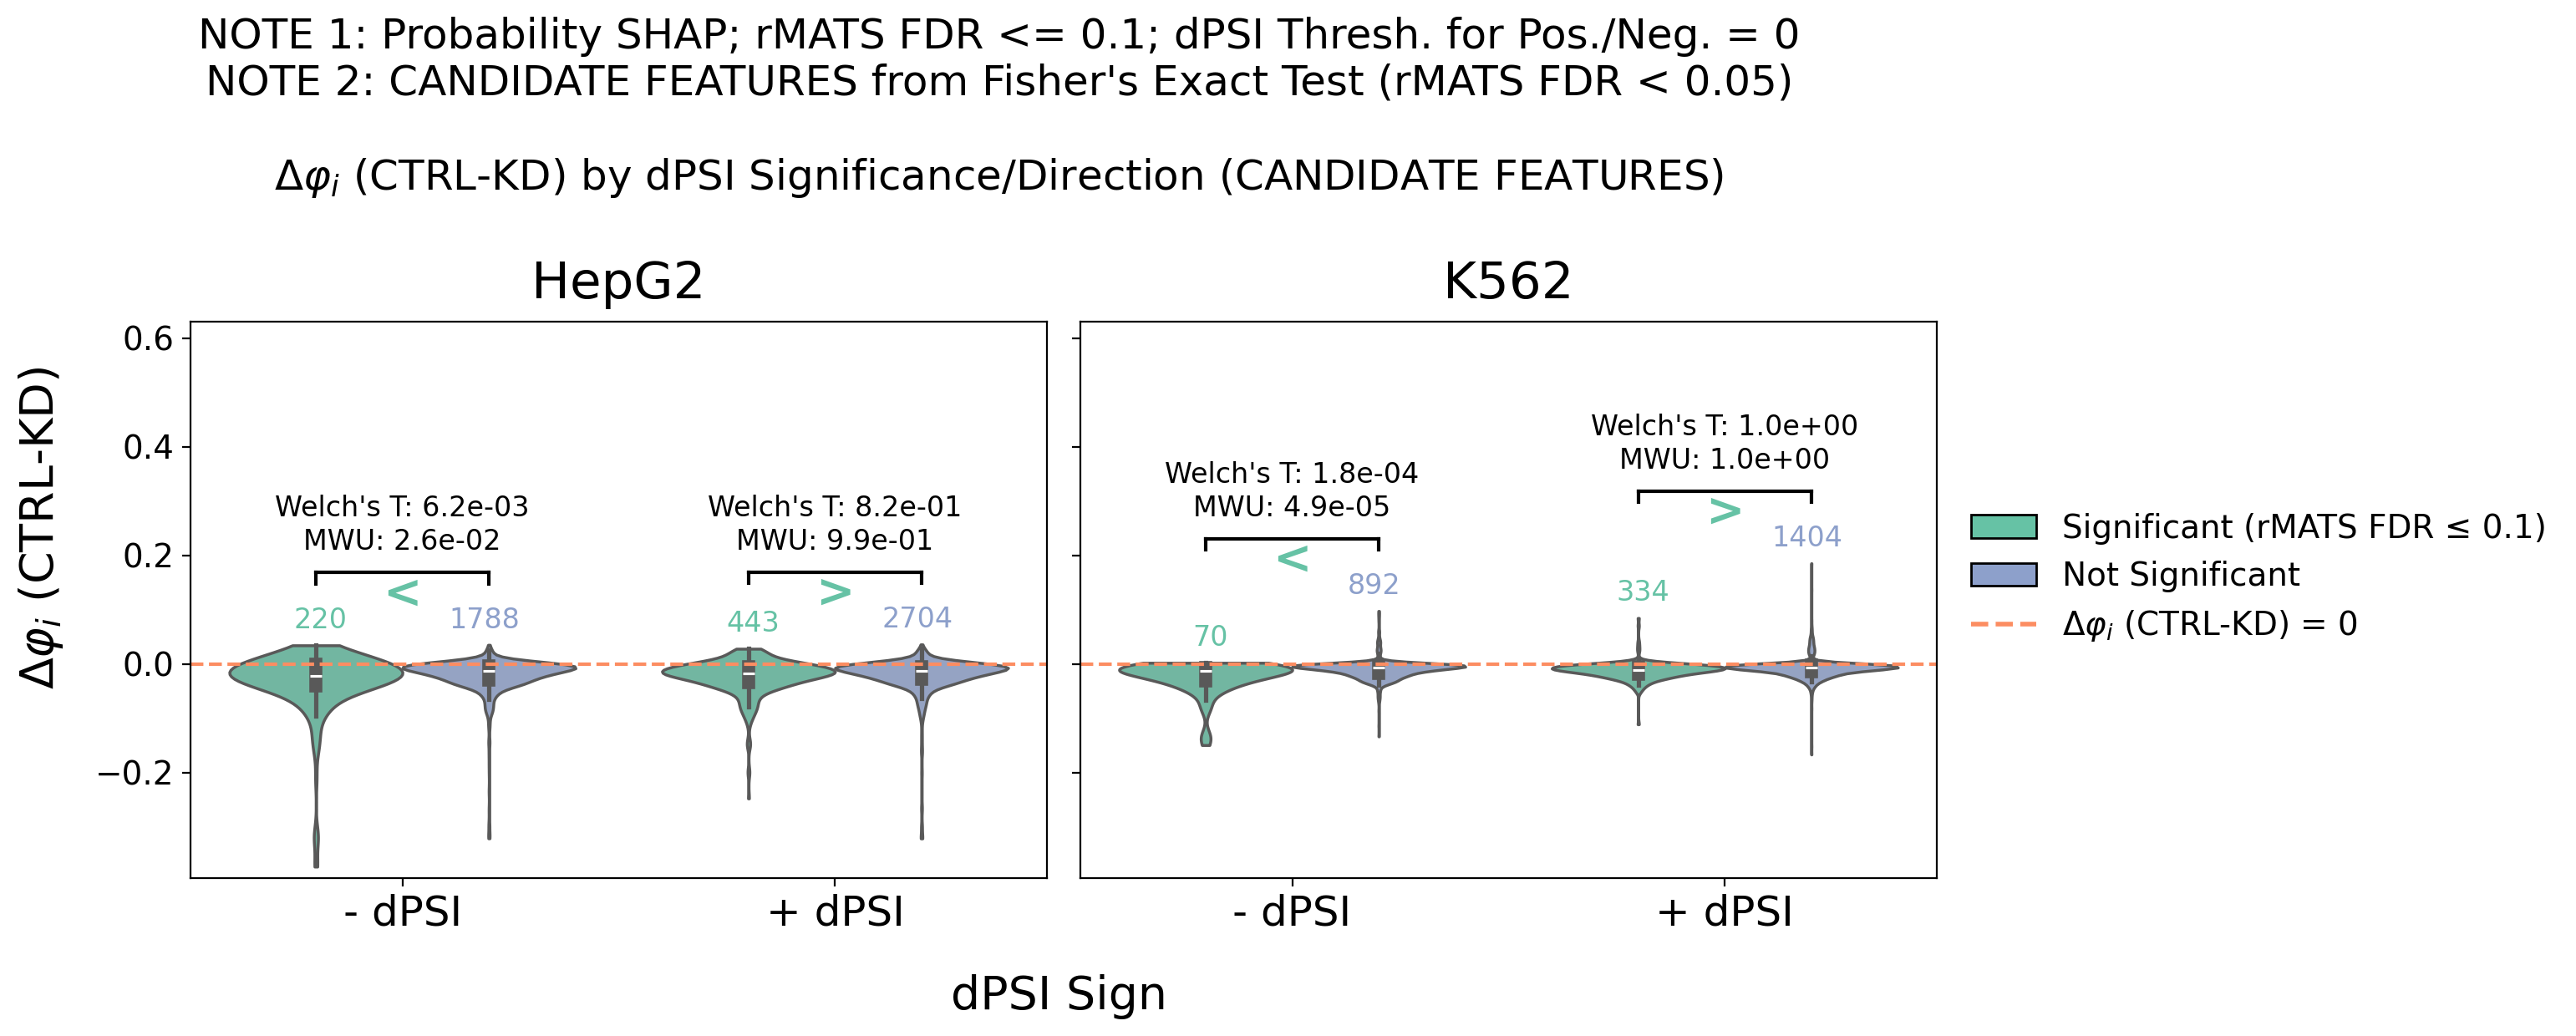

2025-10-02 19:45:05.927 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:06.037 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

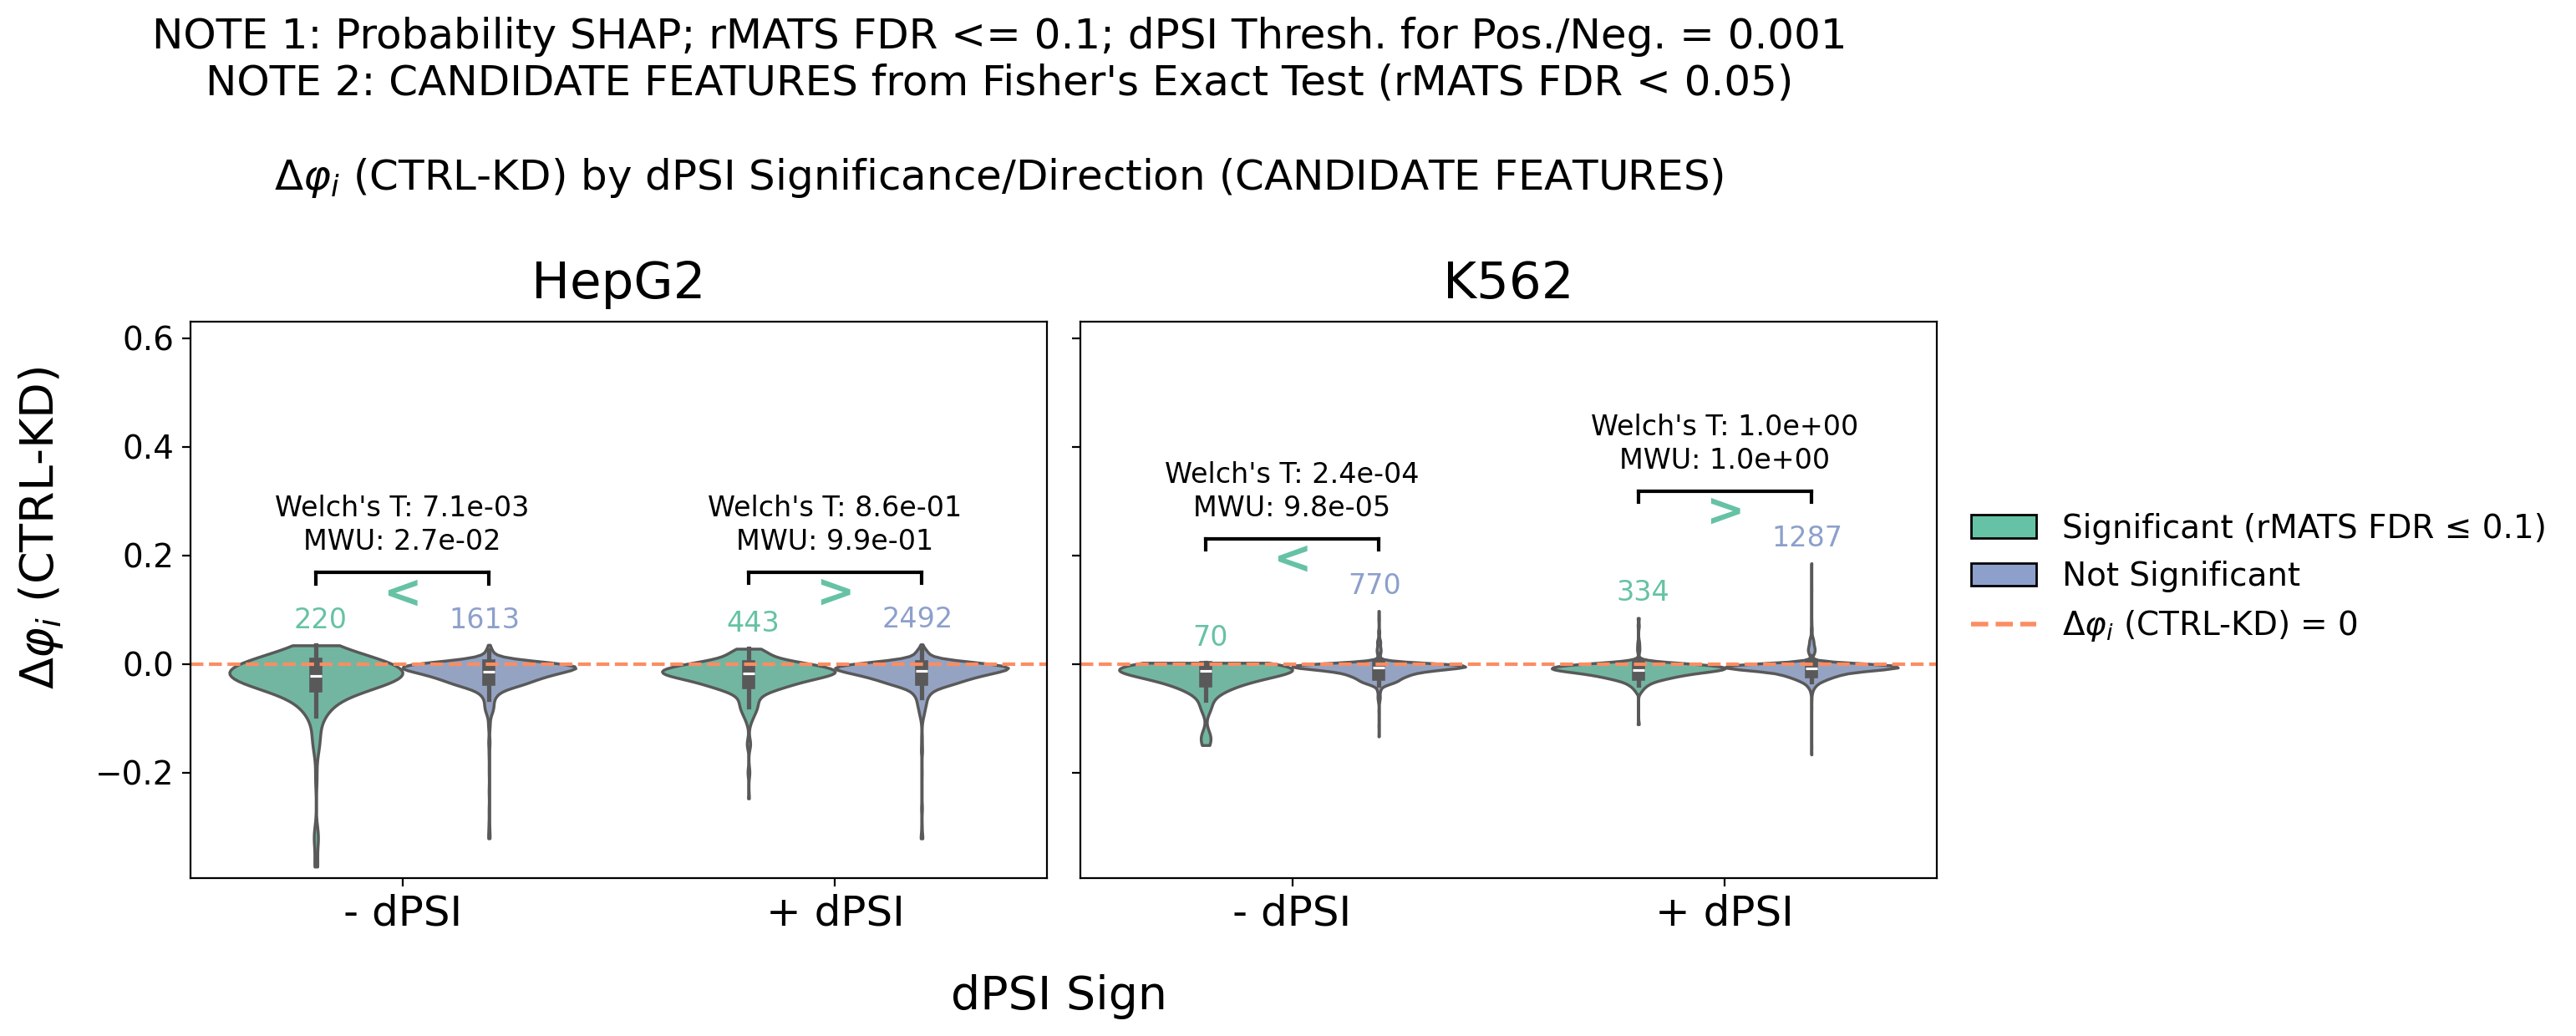

2025-10-02 19:45:06.688 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:06.781 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

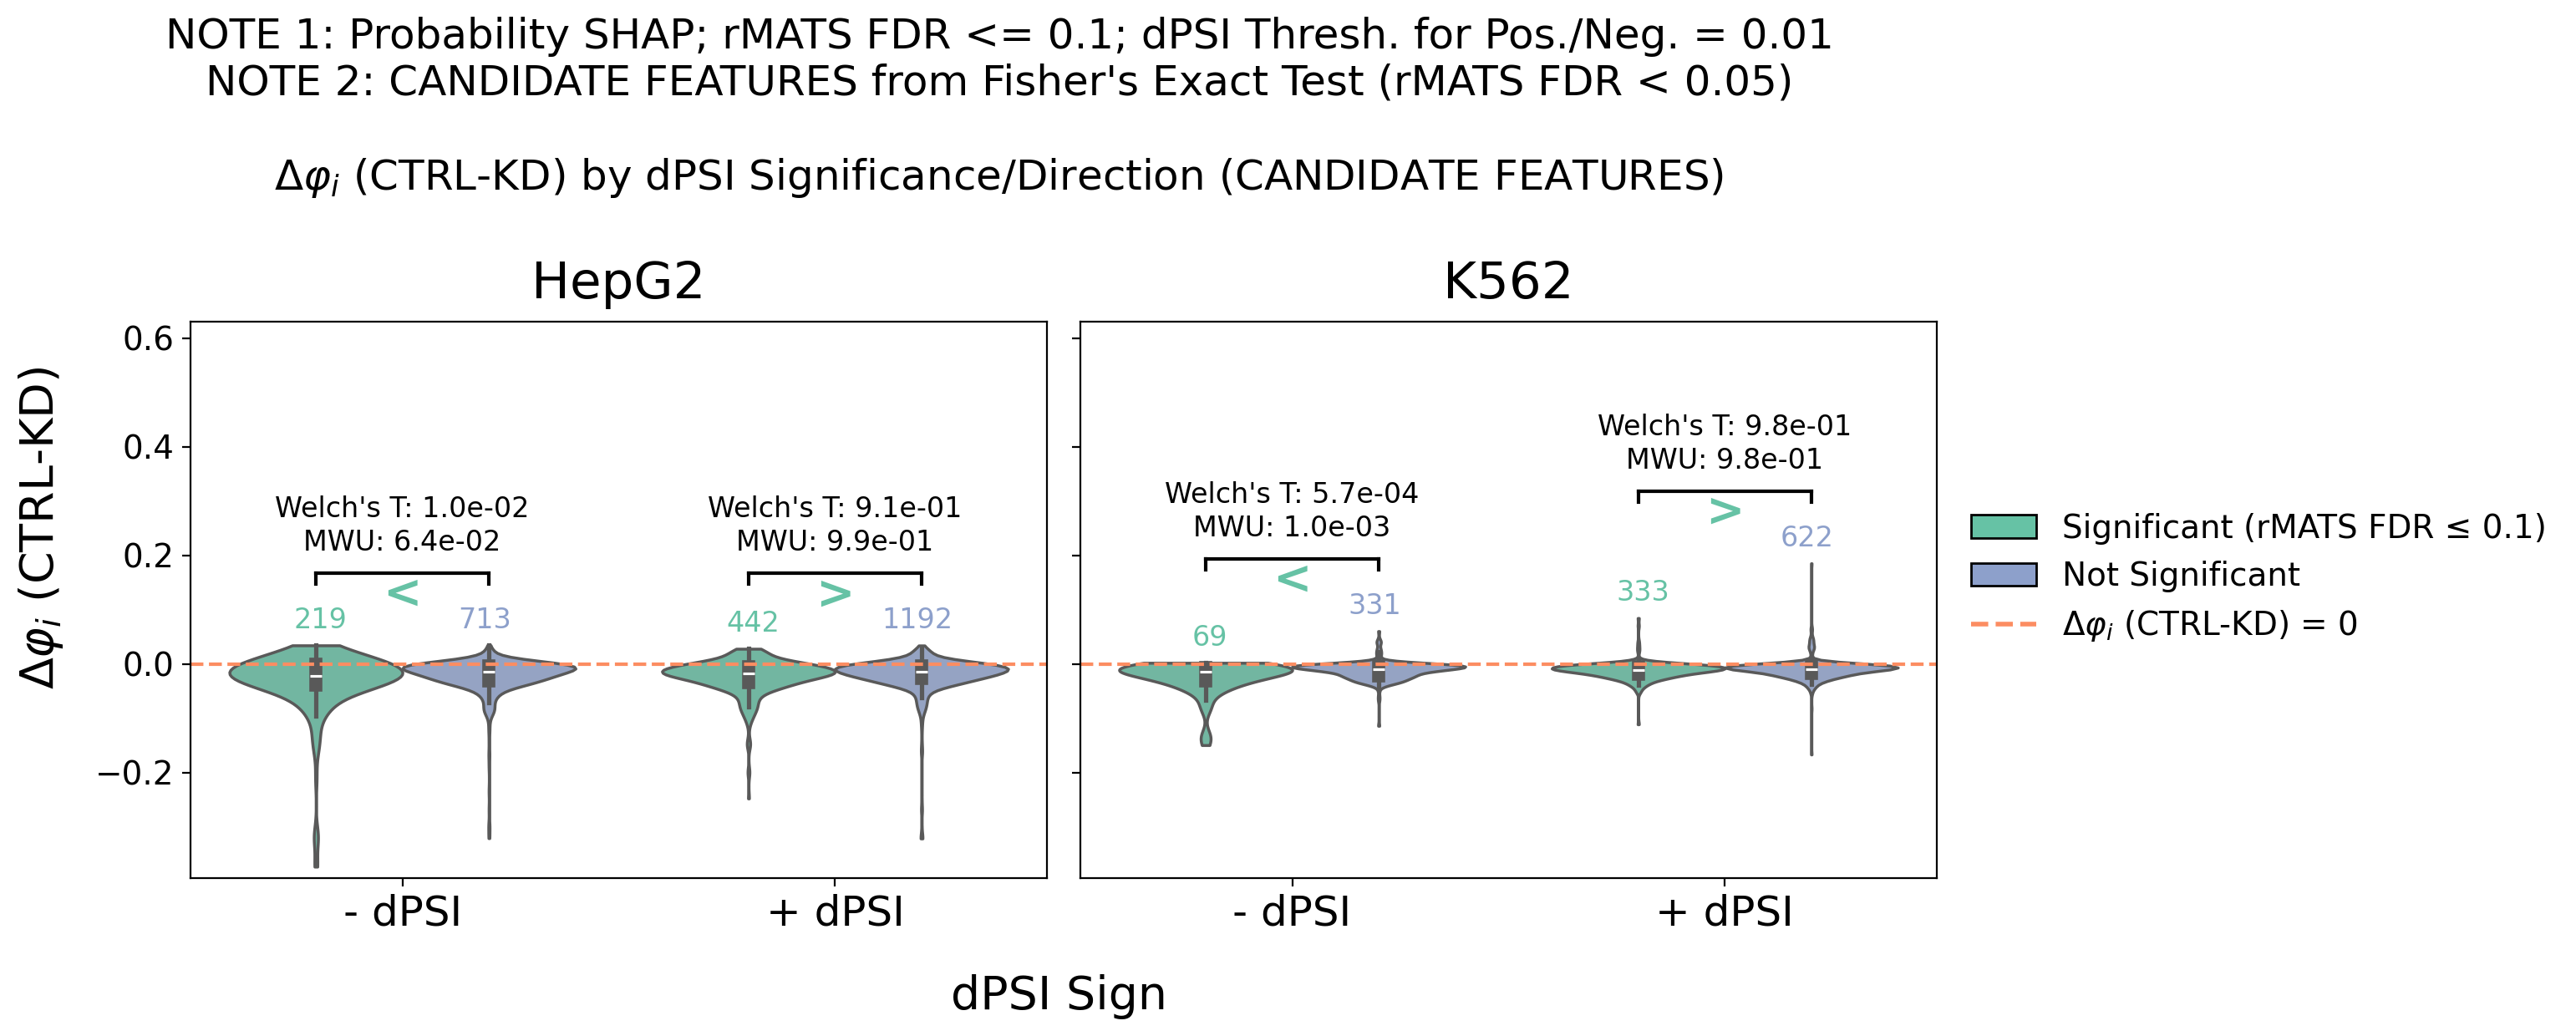

2025-10-02 19:45:07.366 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:07.469 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

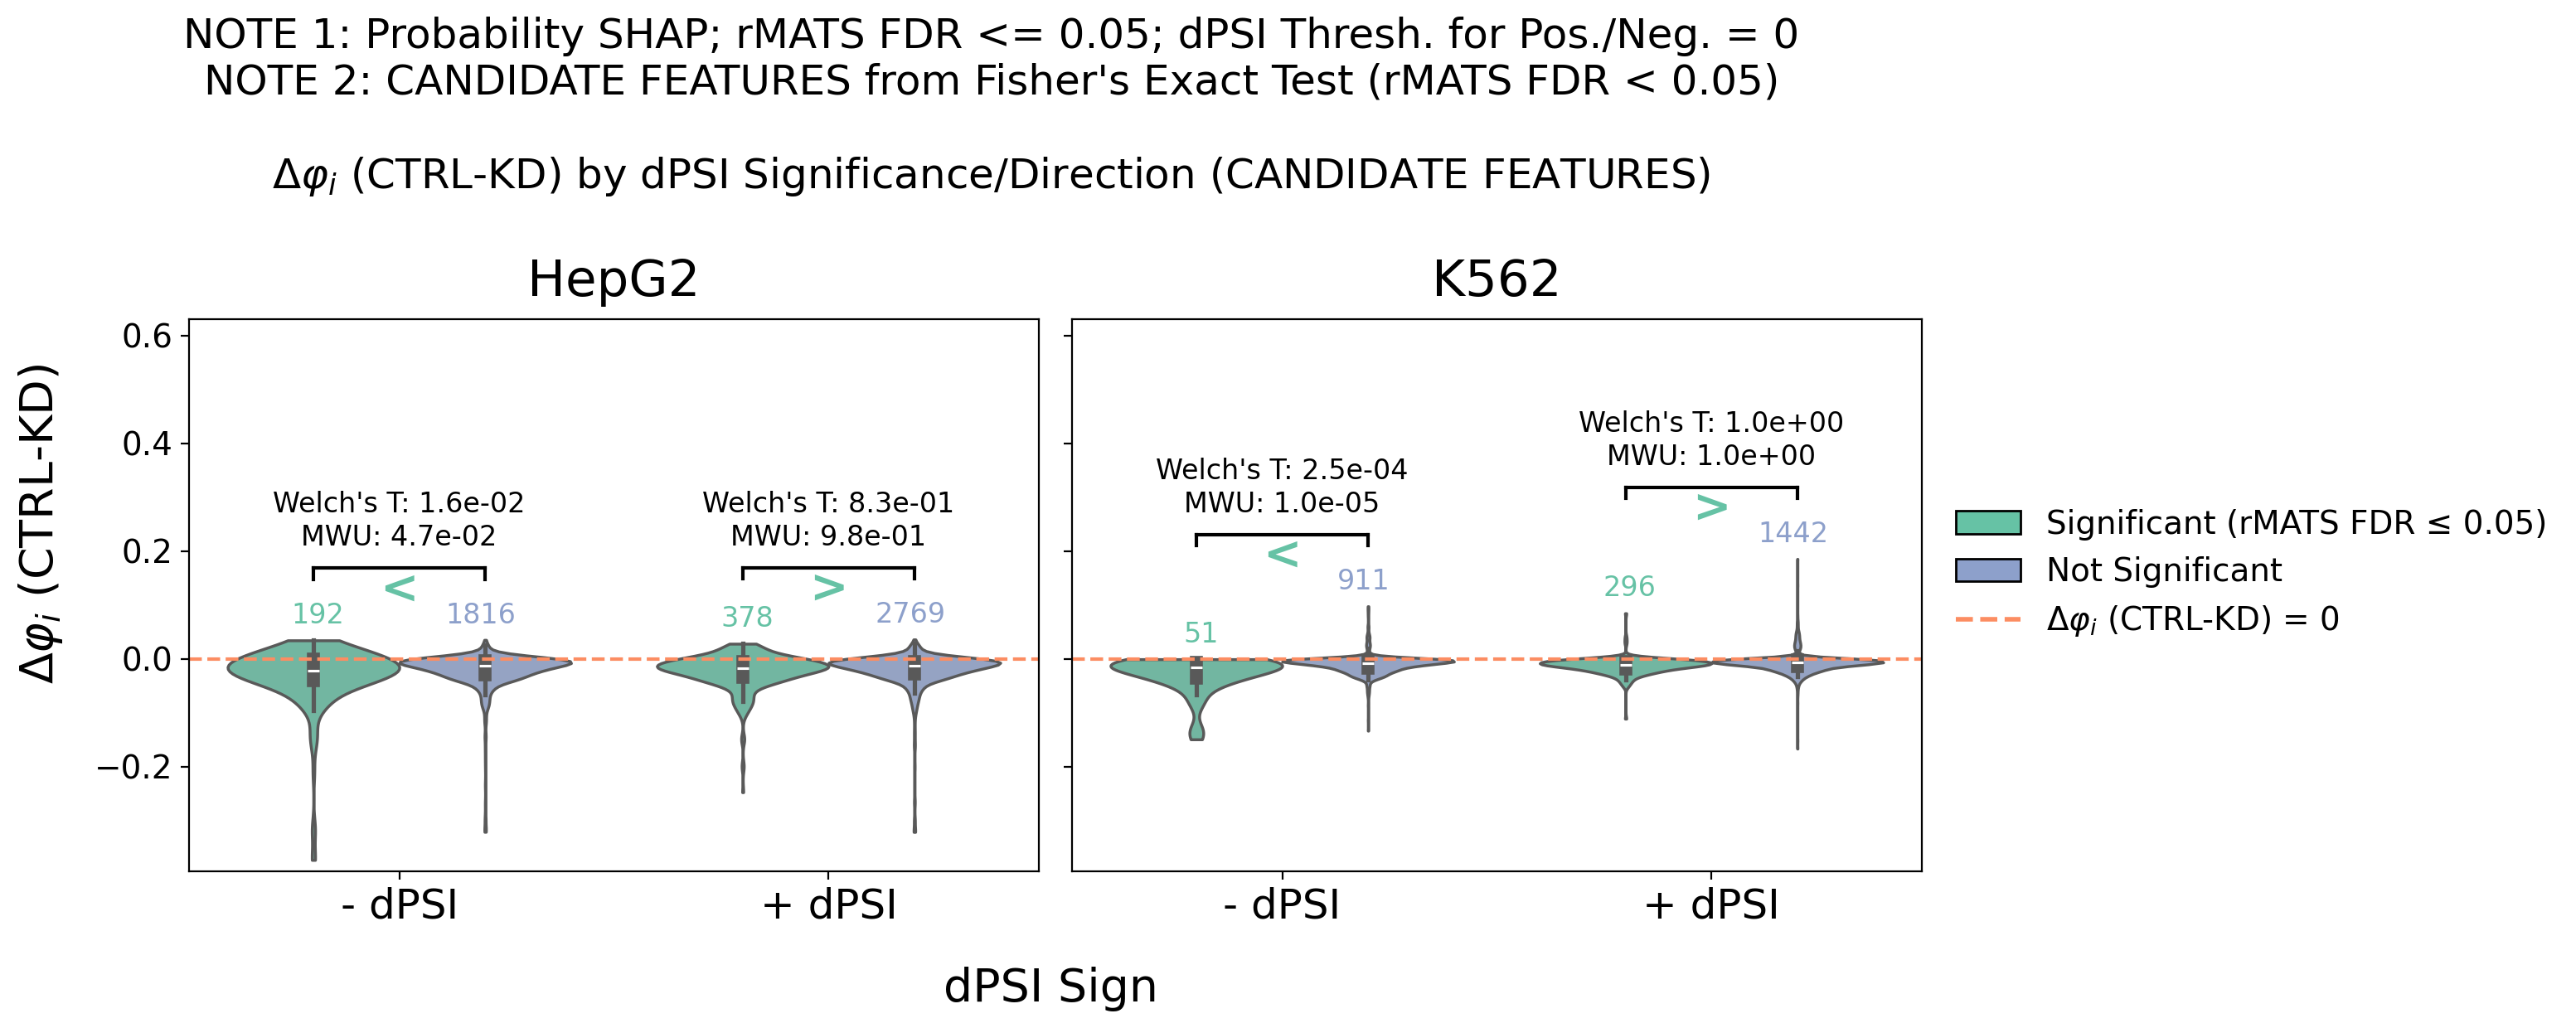

2025-10-02 19:45:08.059 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:08.160 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

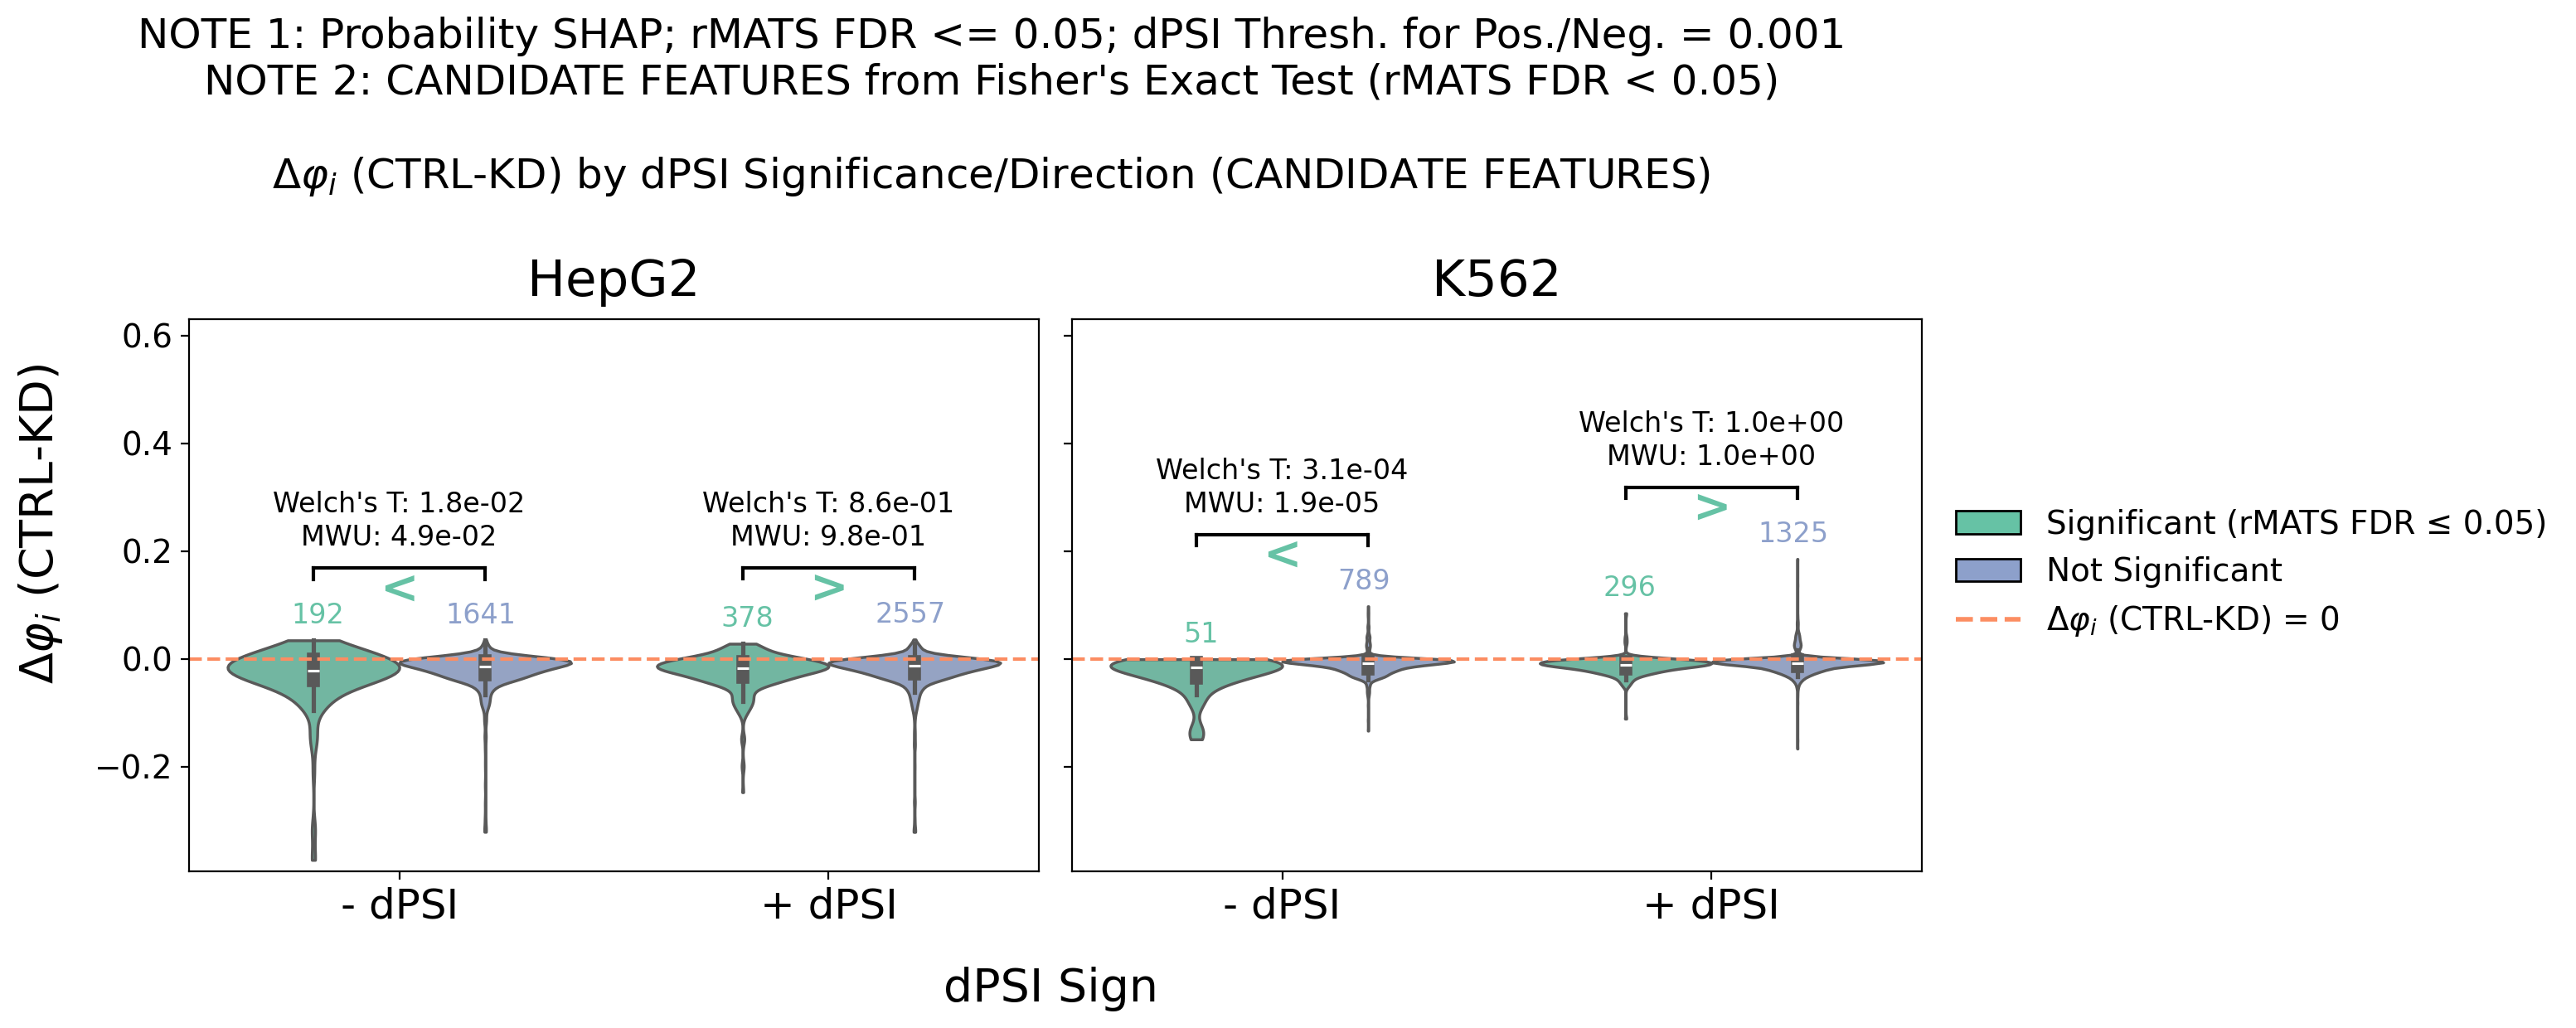

2025-10-02 19:45:08.752 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:08.843 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

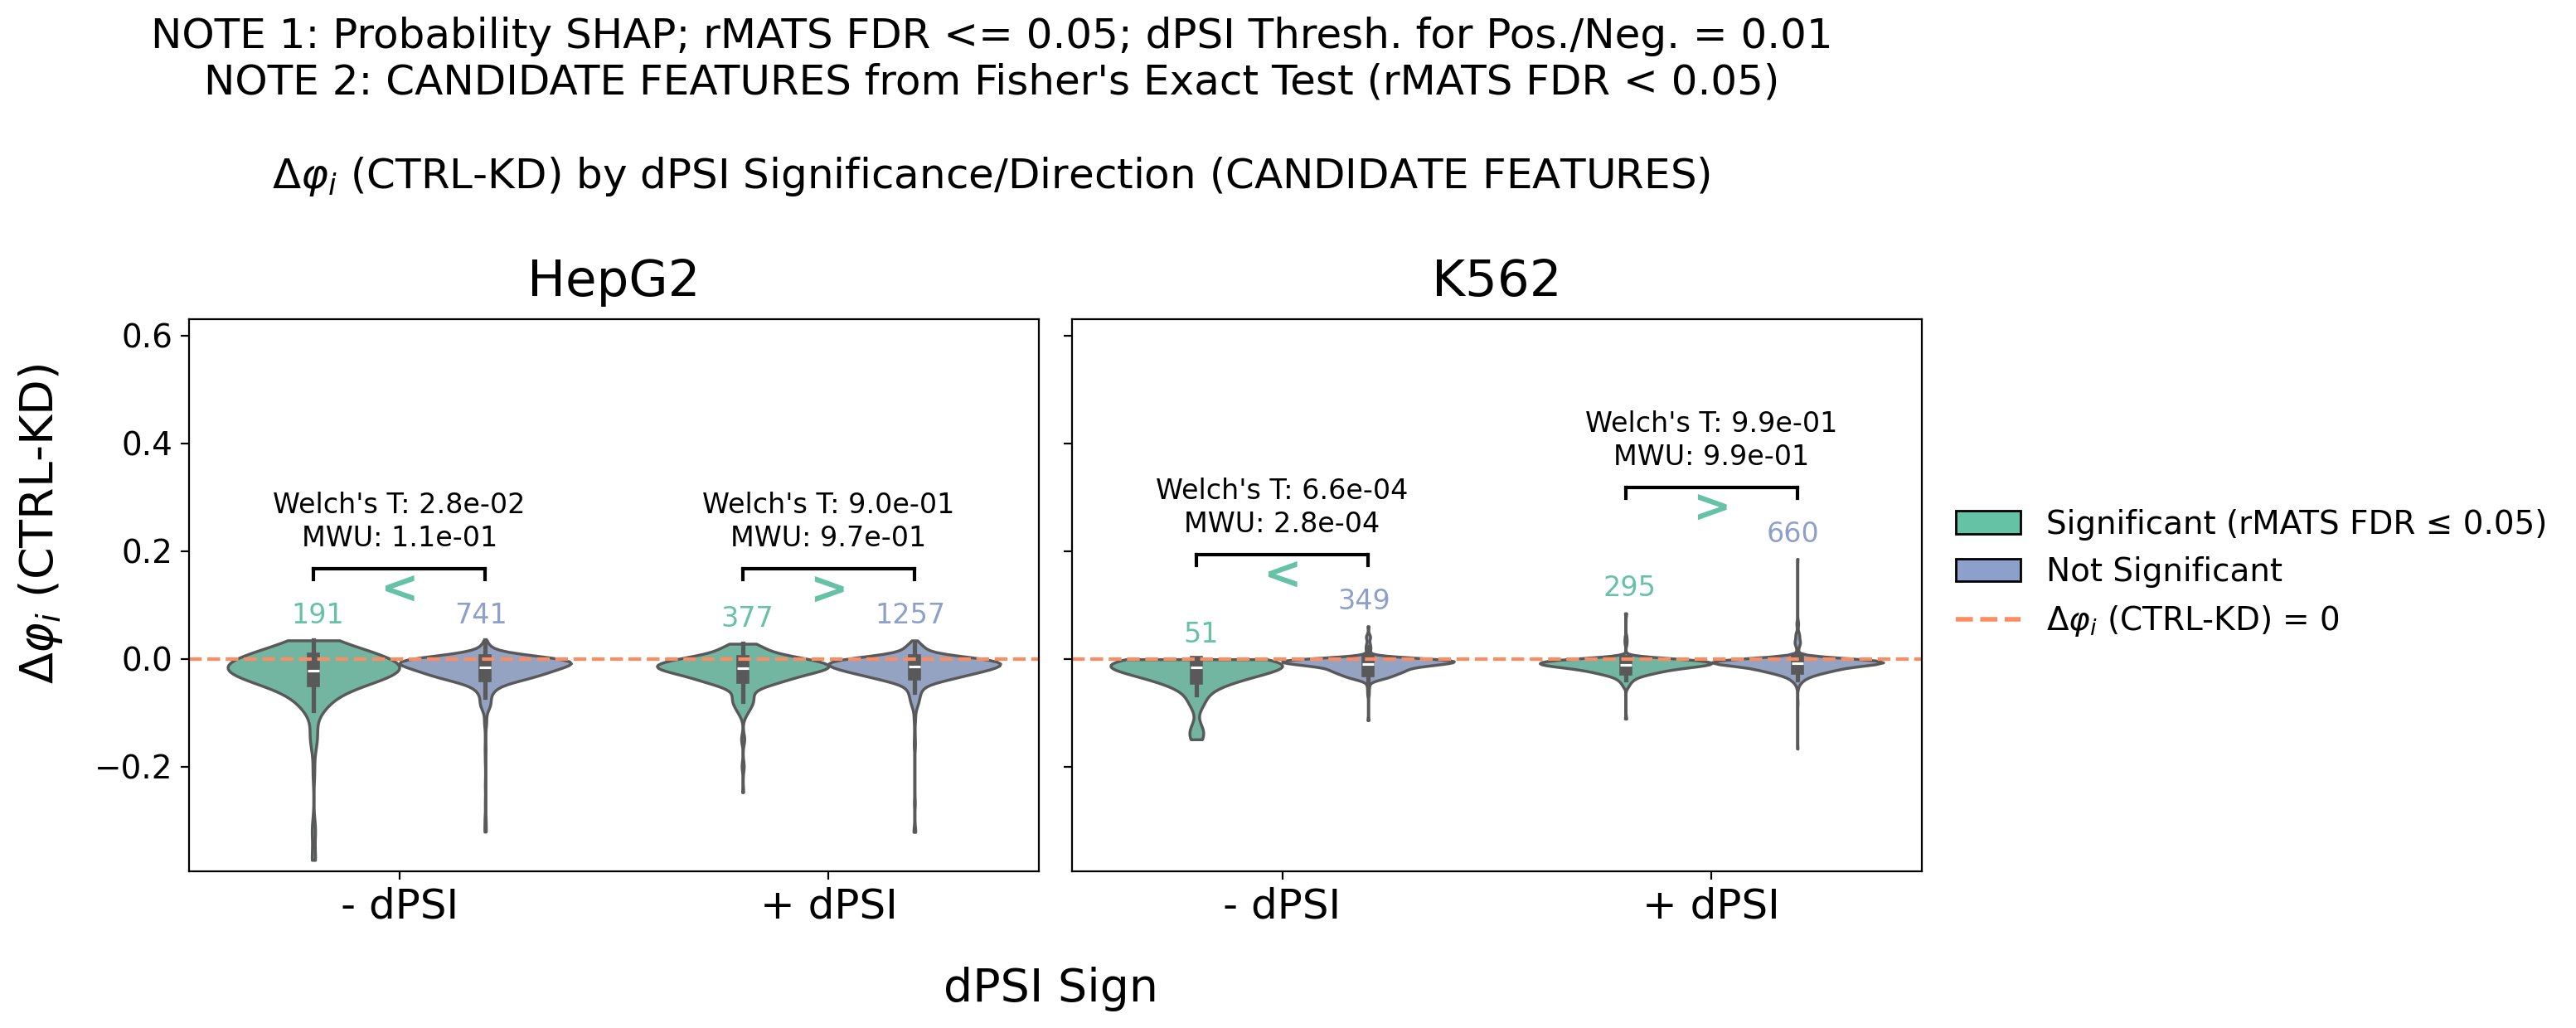

2025-10-02 19:45:09.496 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:09.599 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

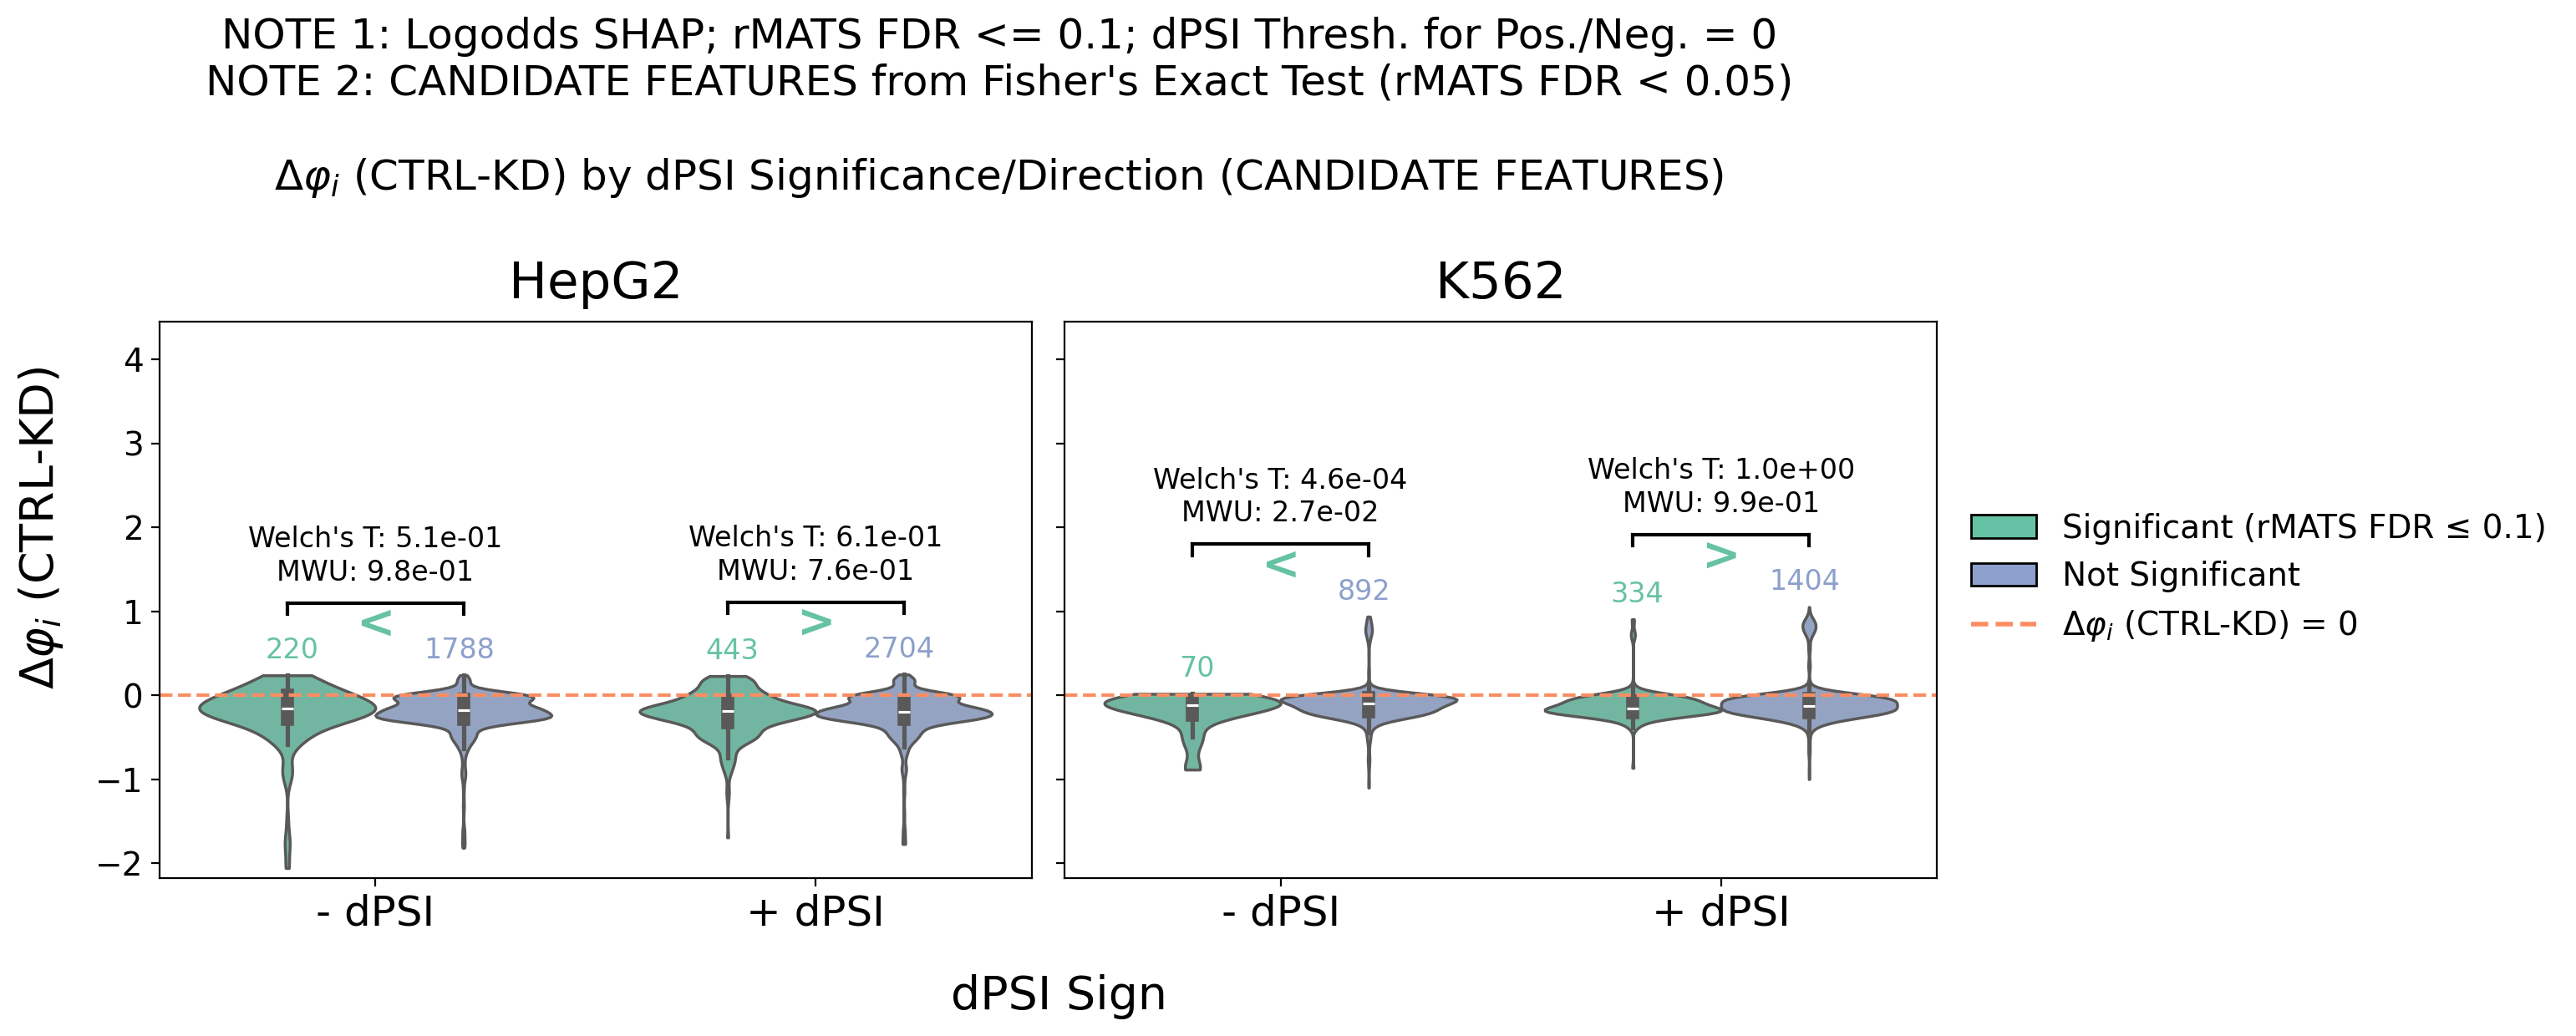

2025-10-02 19:45:10.196 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:10.299 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

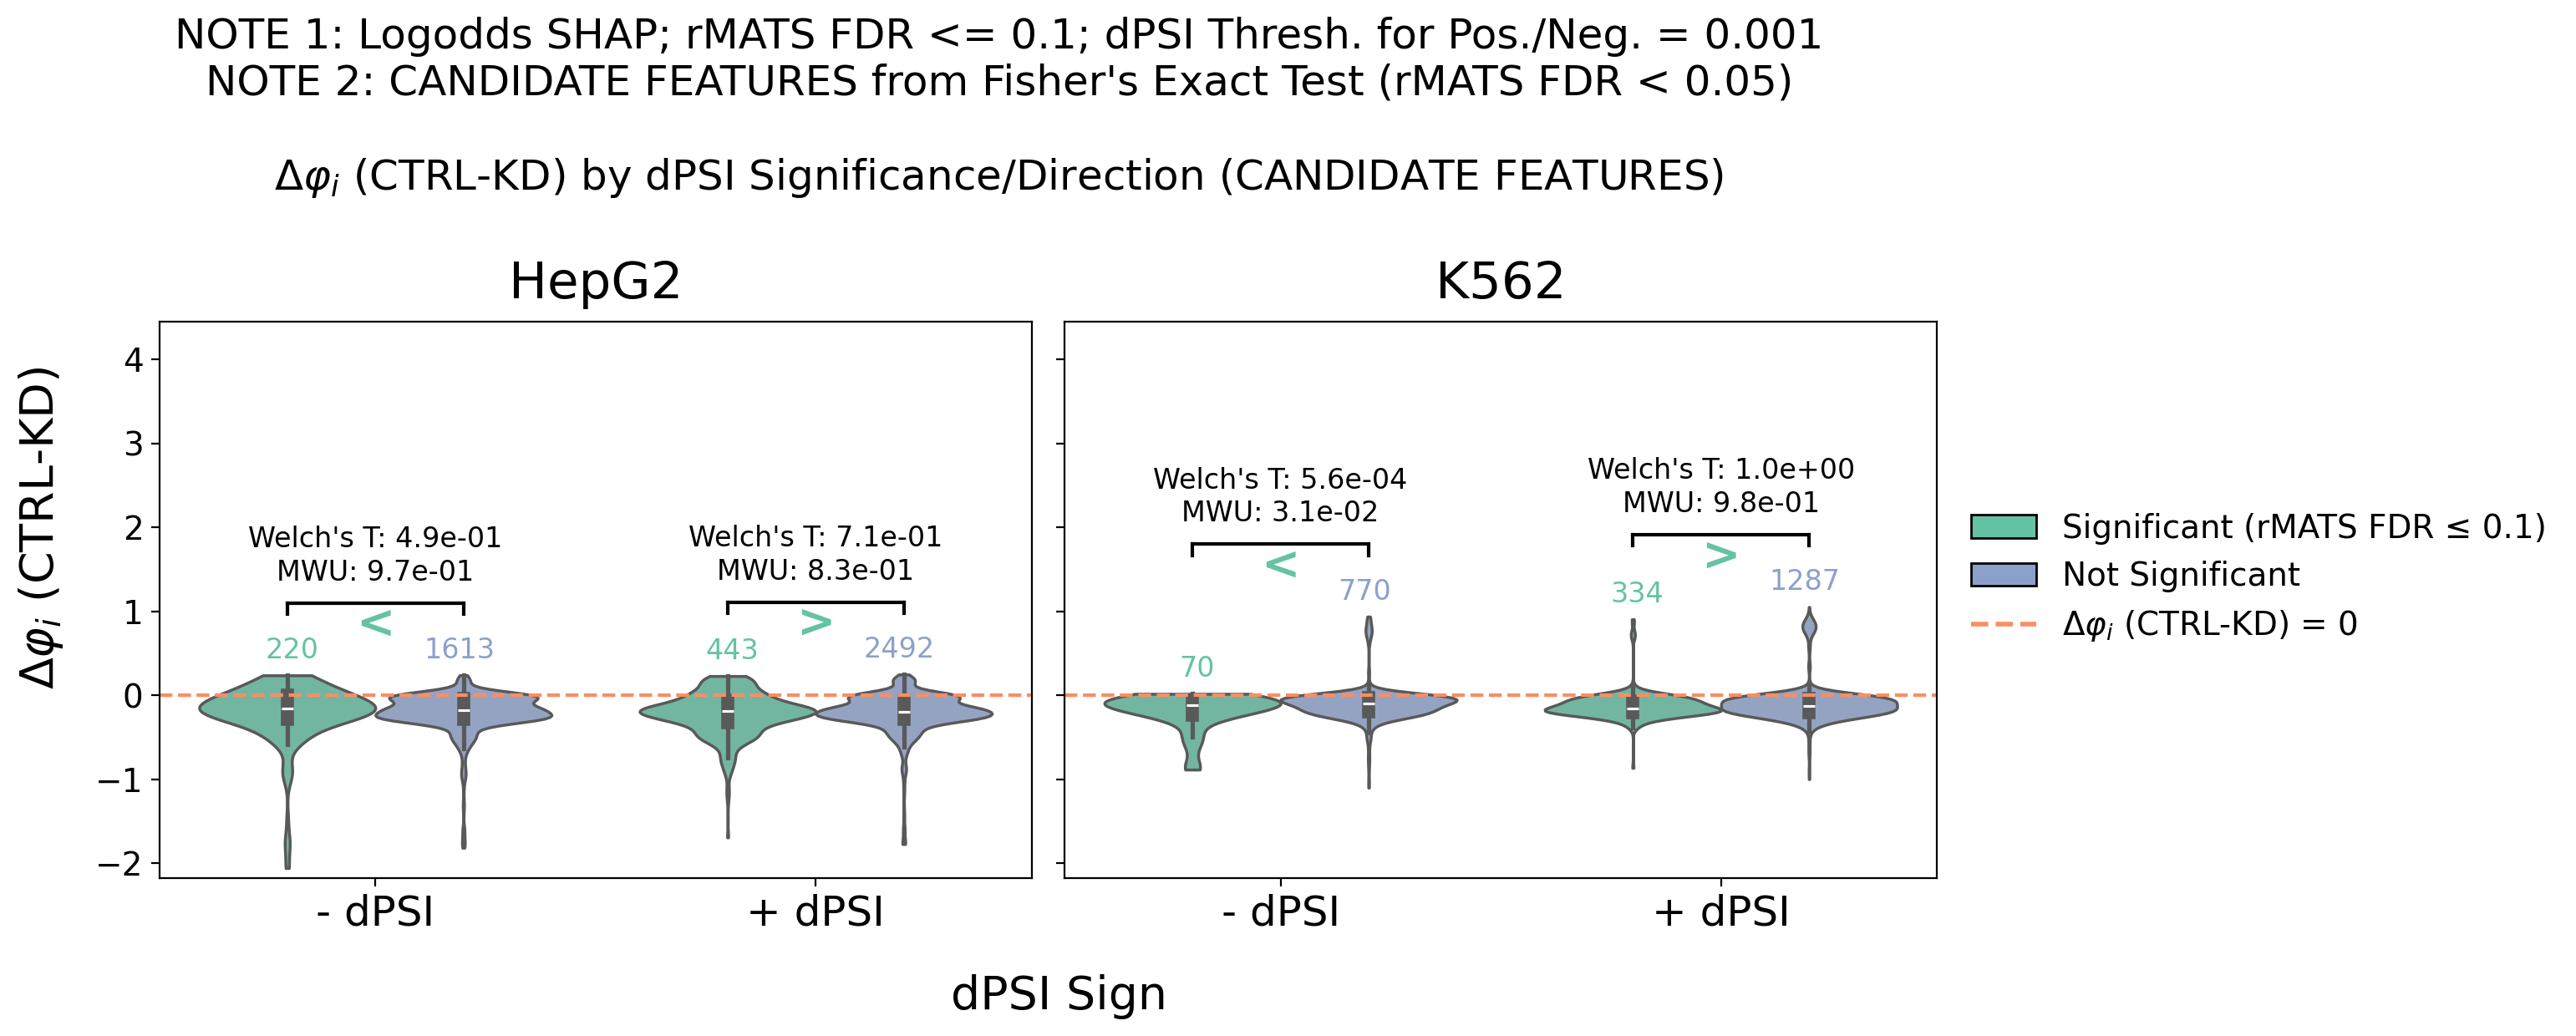

2025-10-02 19:45:10.903 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:11.019 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

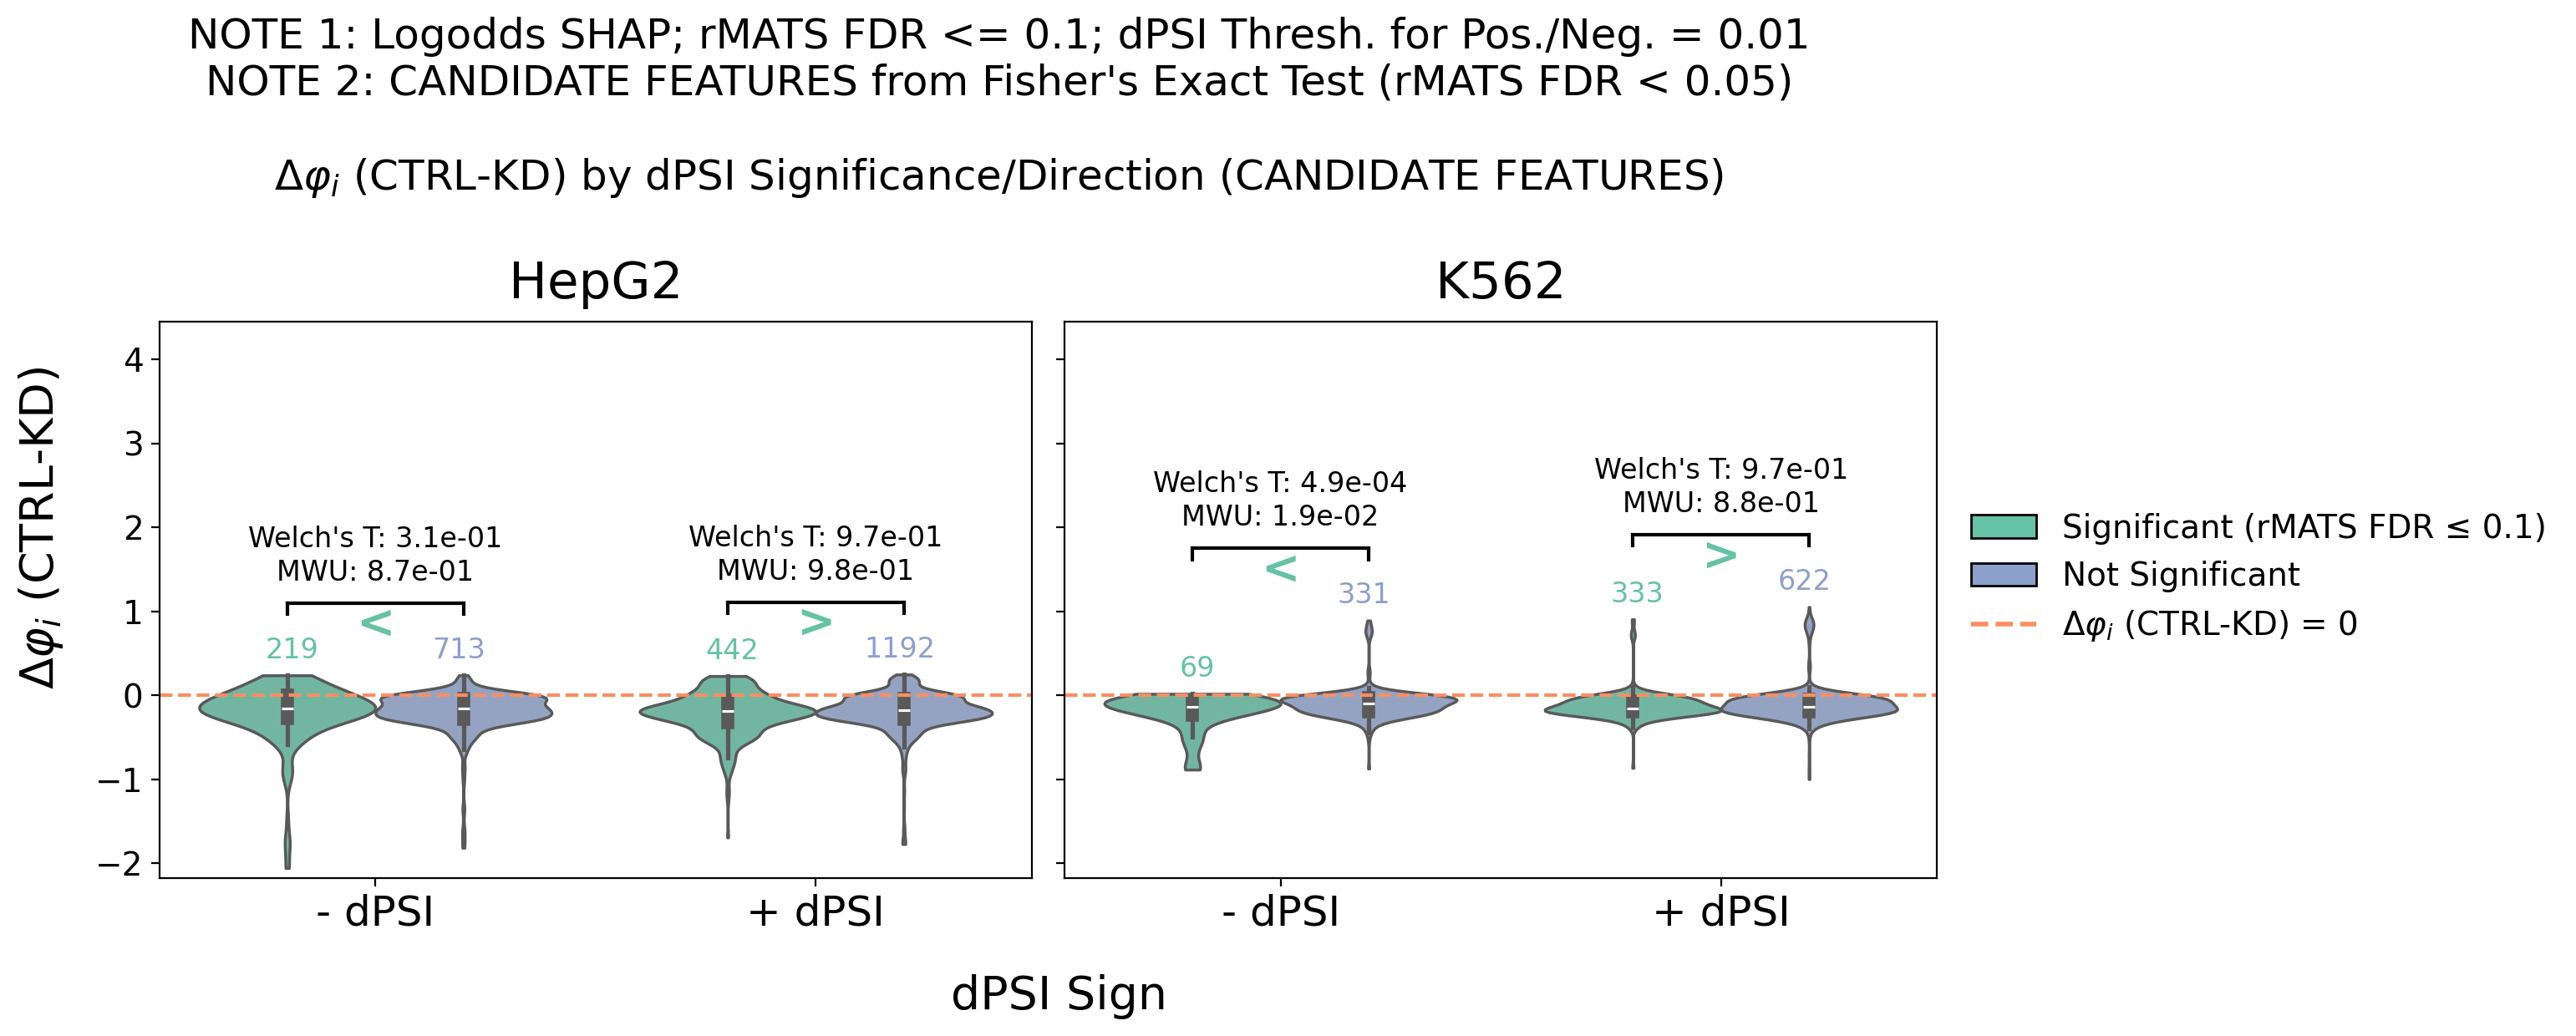

2025-10-02 19:45:11.698 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:11.808 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

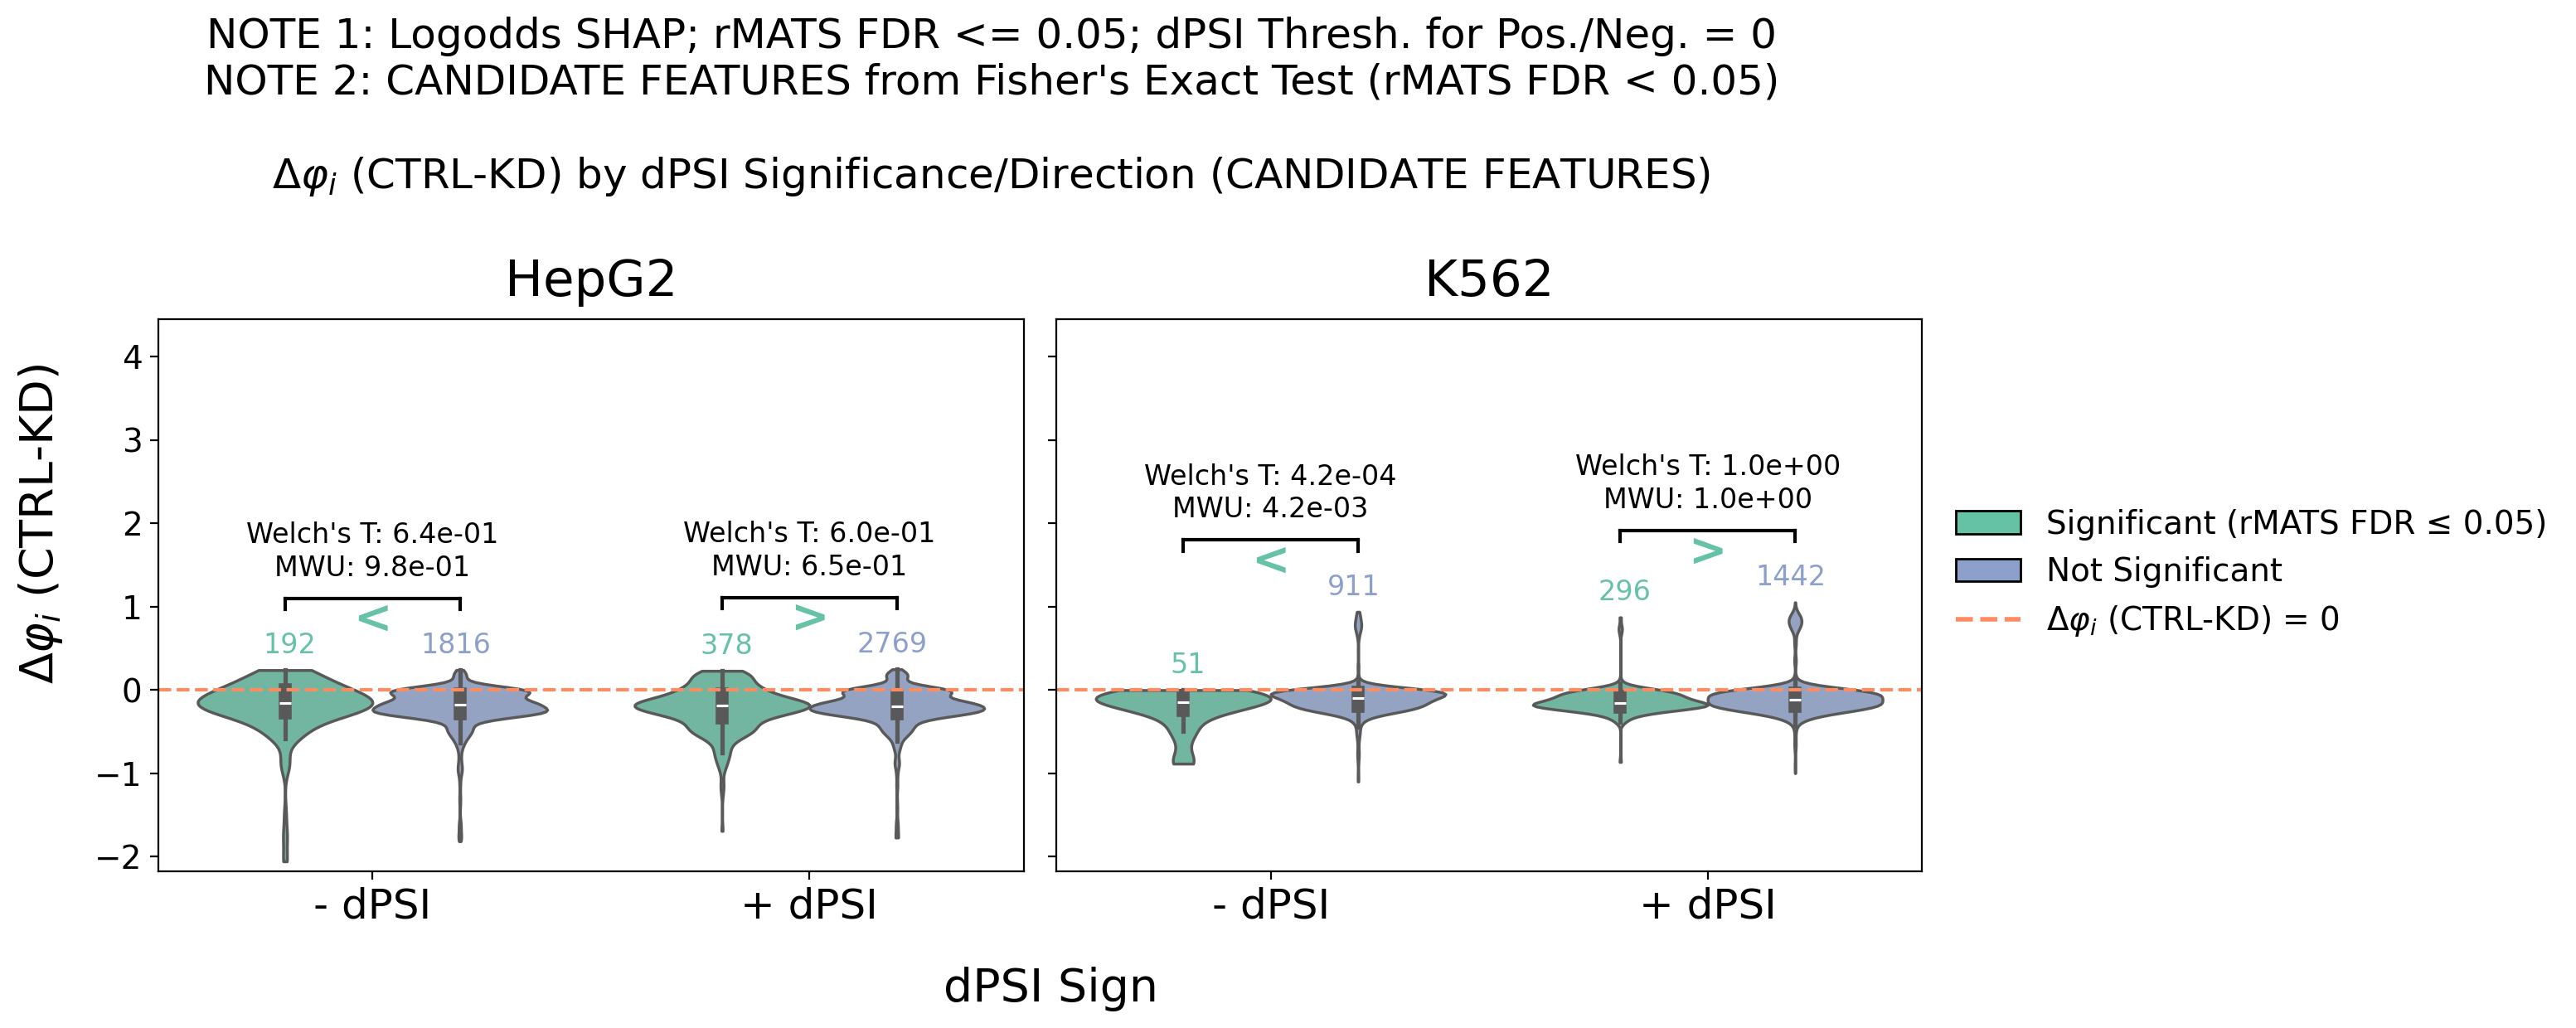

2025-10-02 19:45:12.423 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:12.545 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

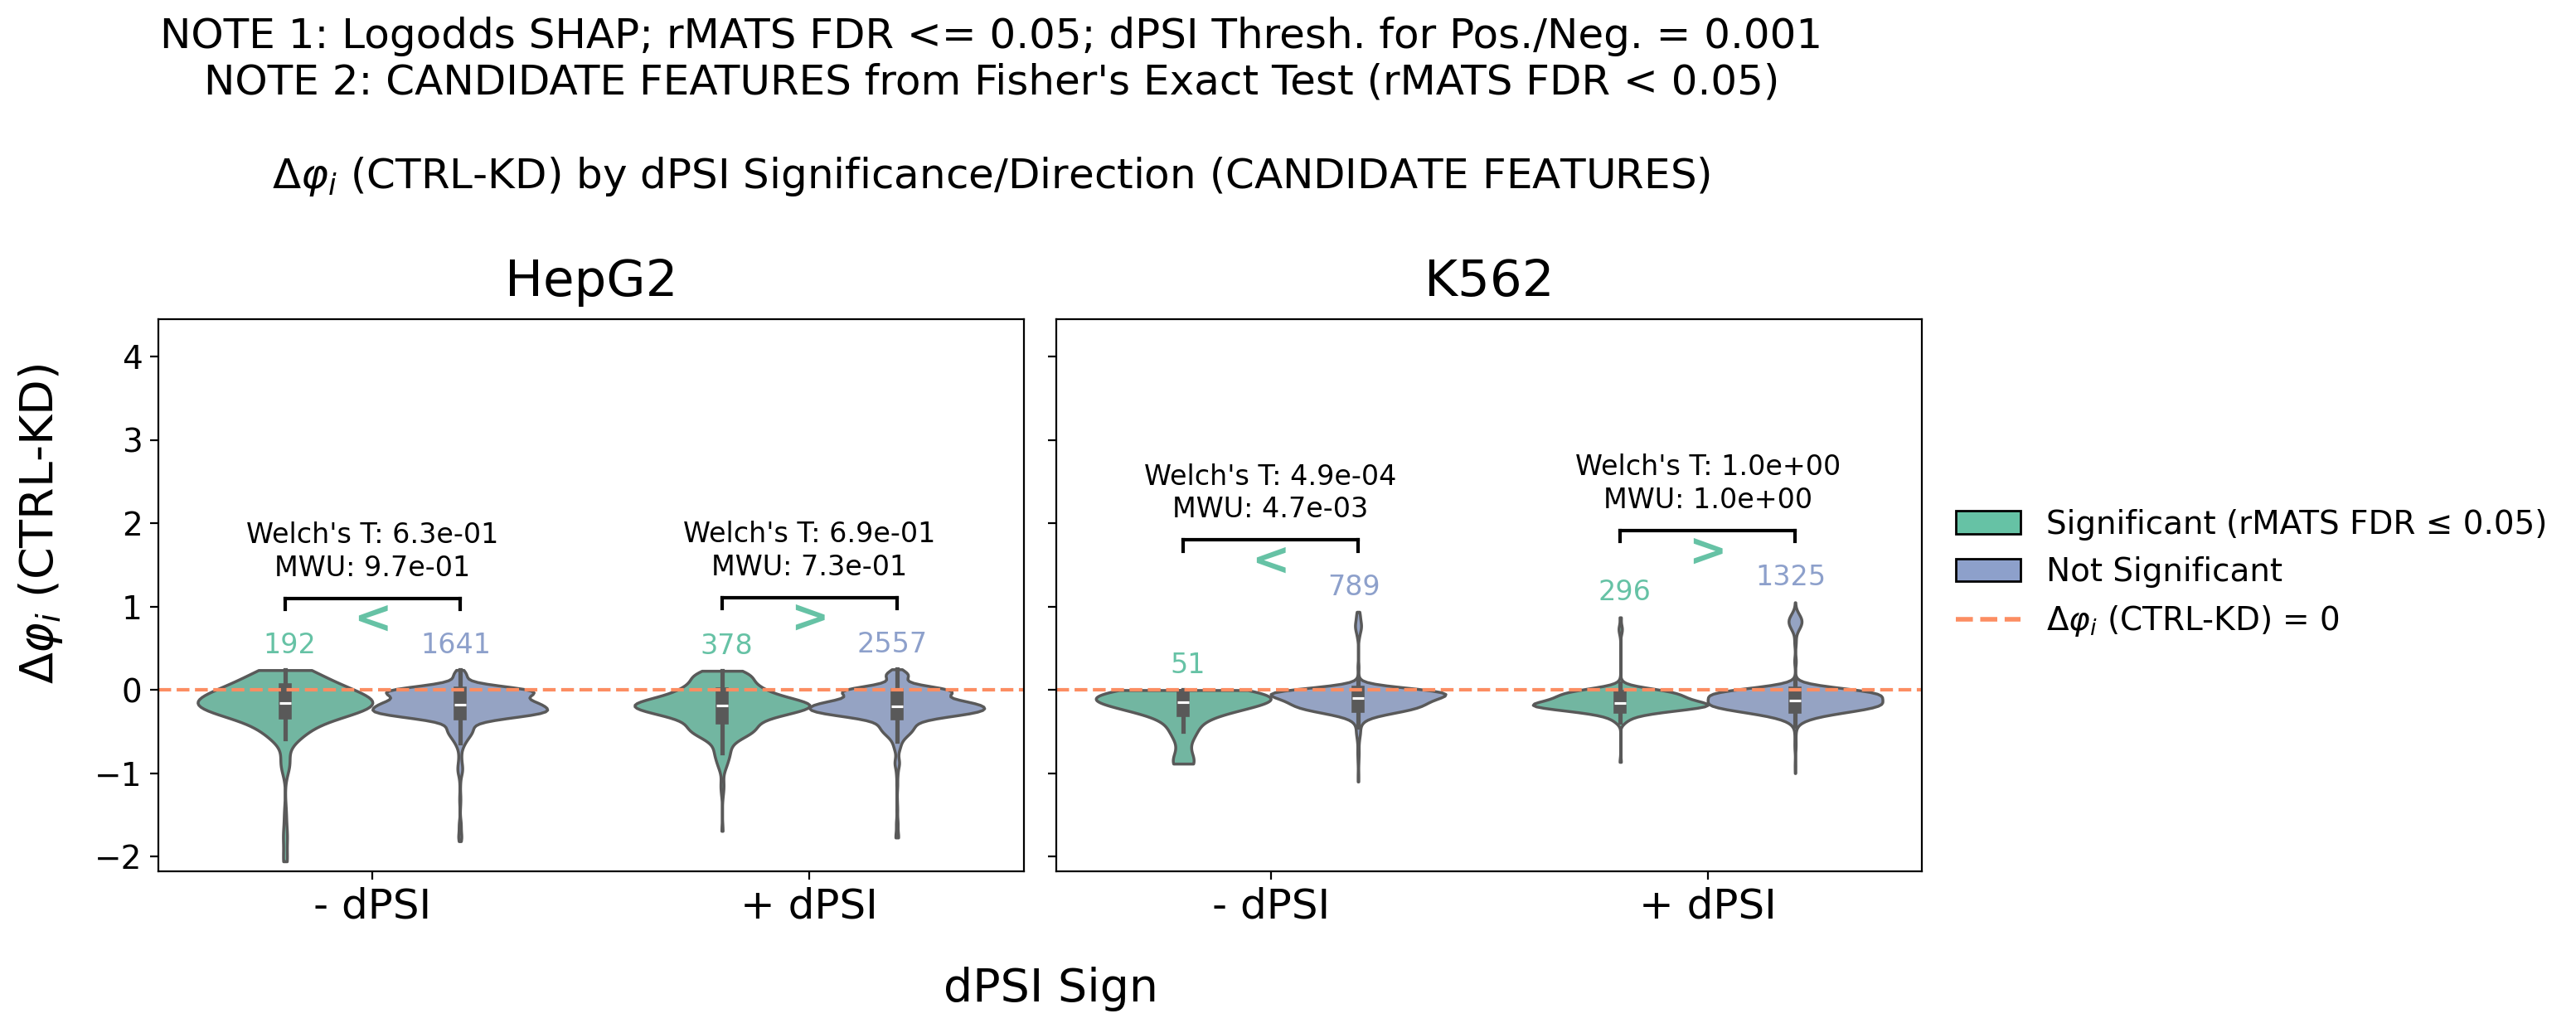

2025-10-02 19:45:13.166 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
2025-10-02 19:45:13.254 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8356 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_anal

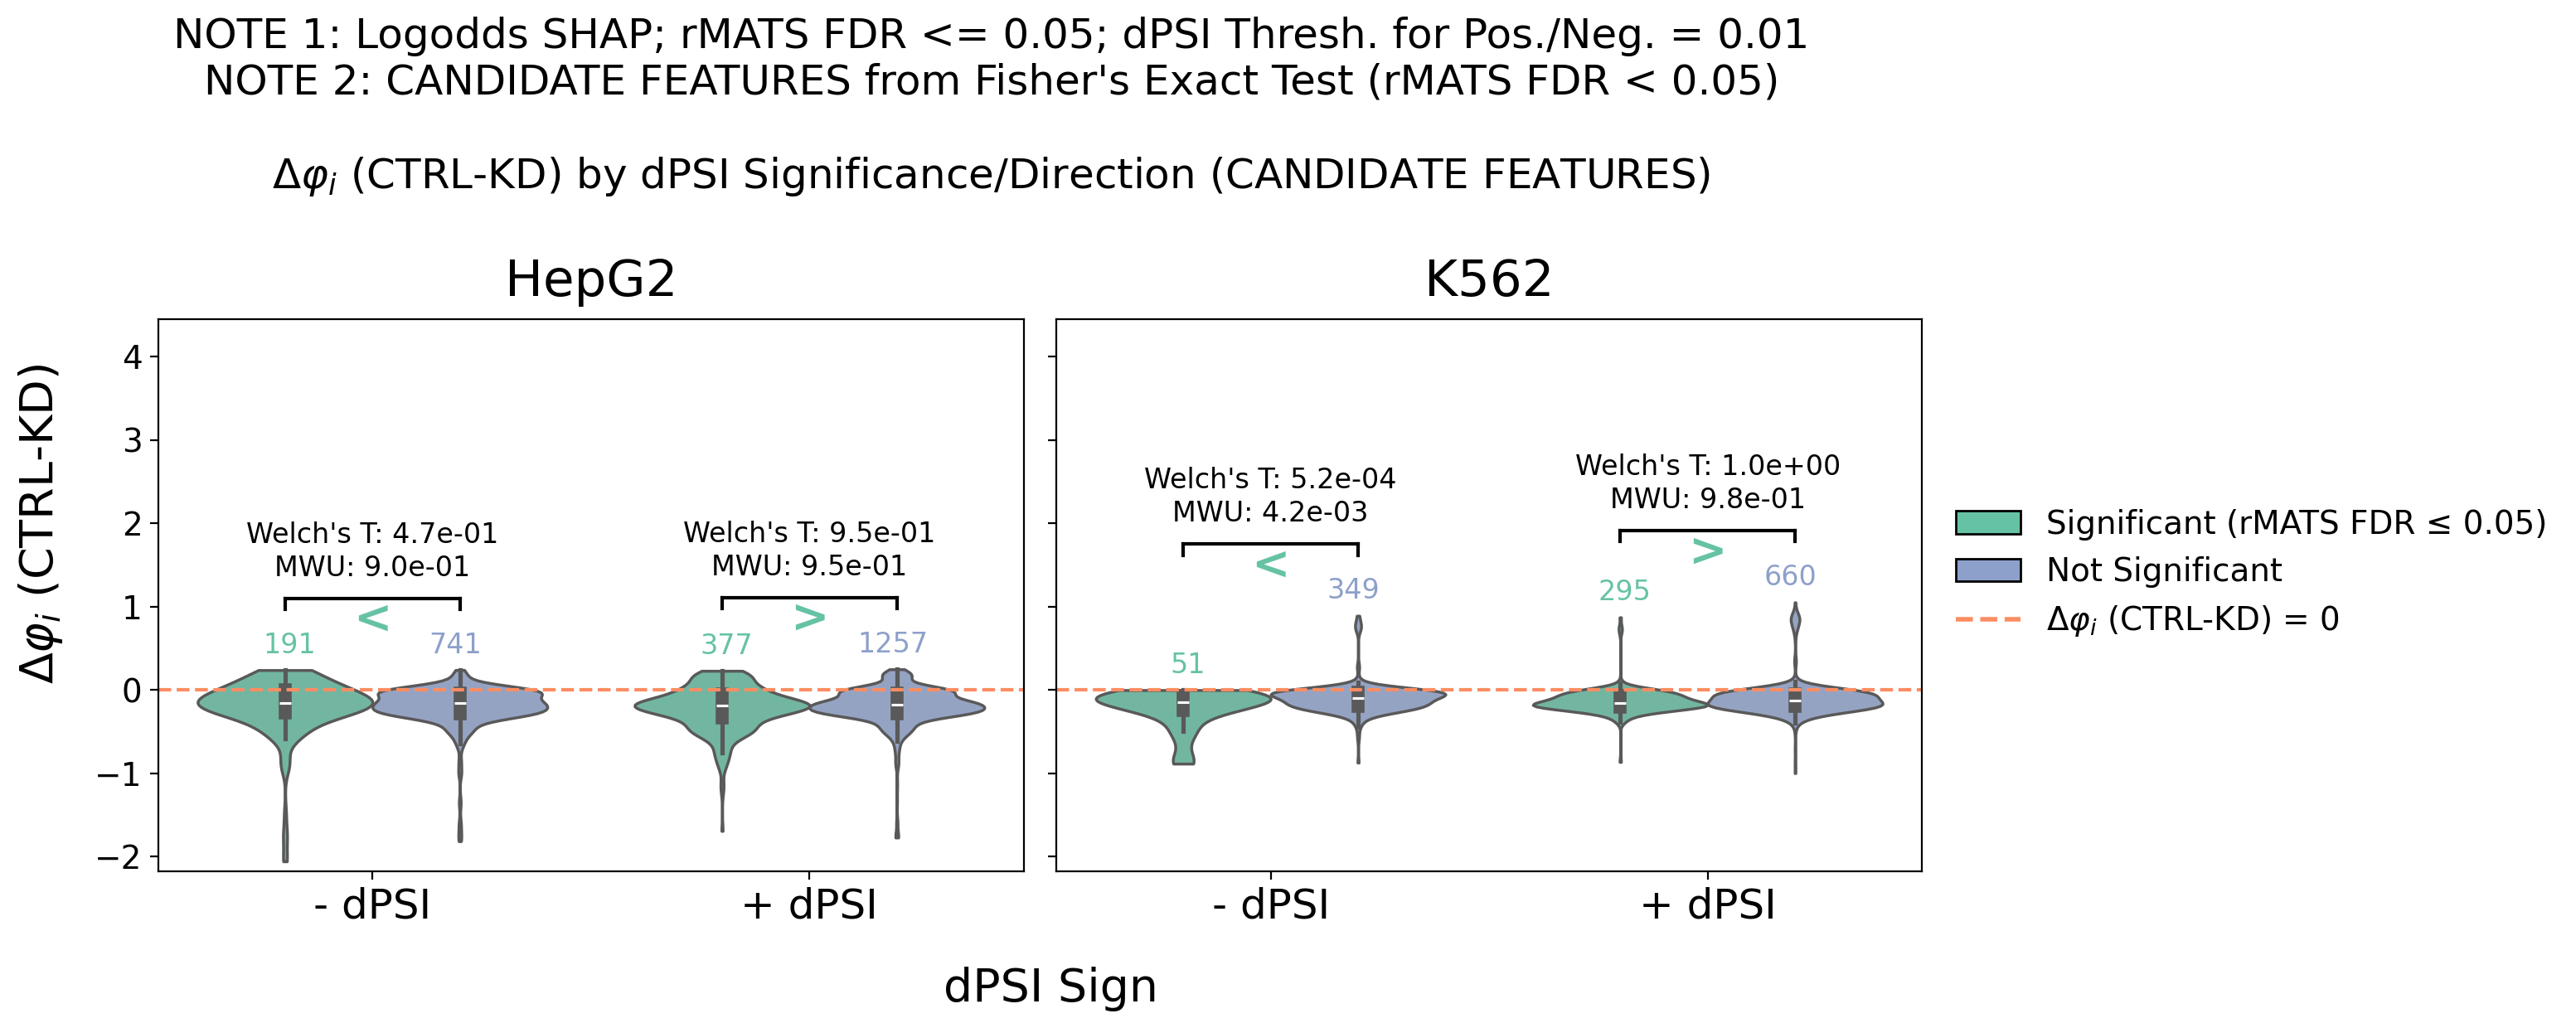

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


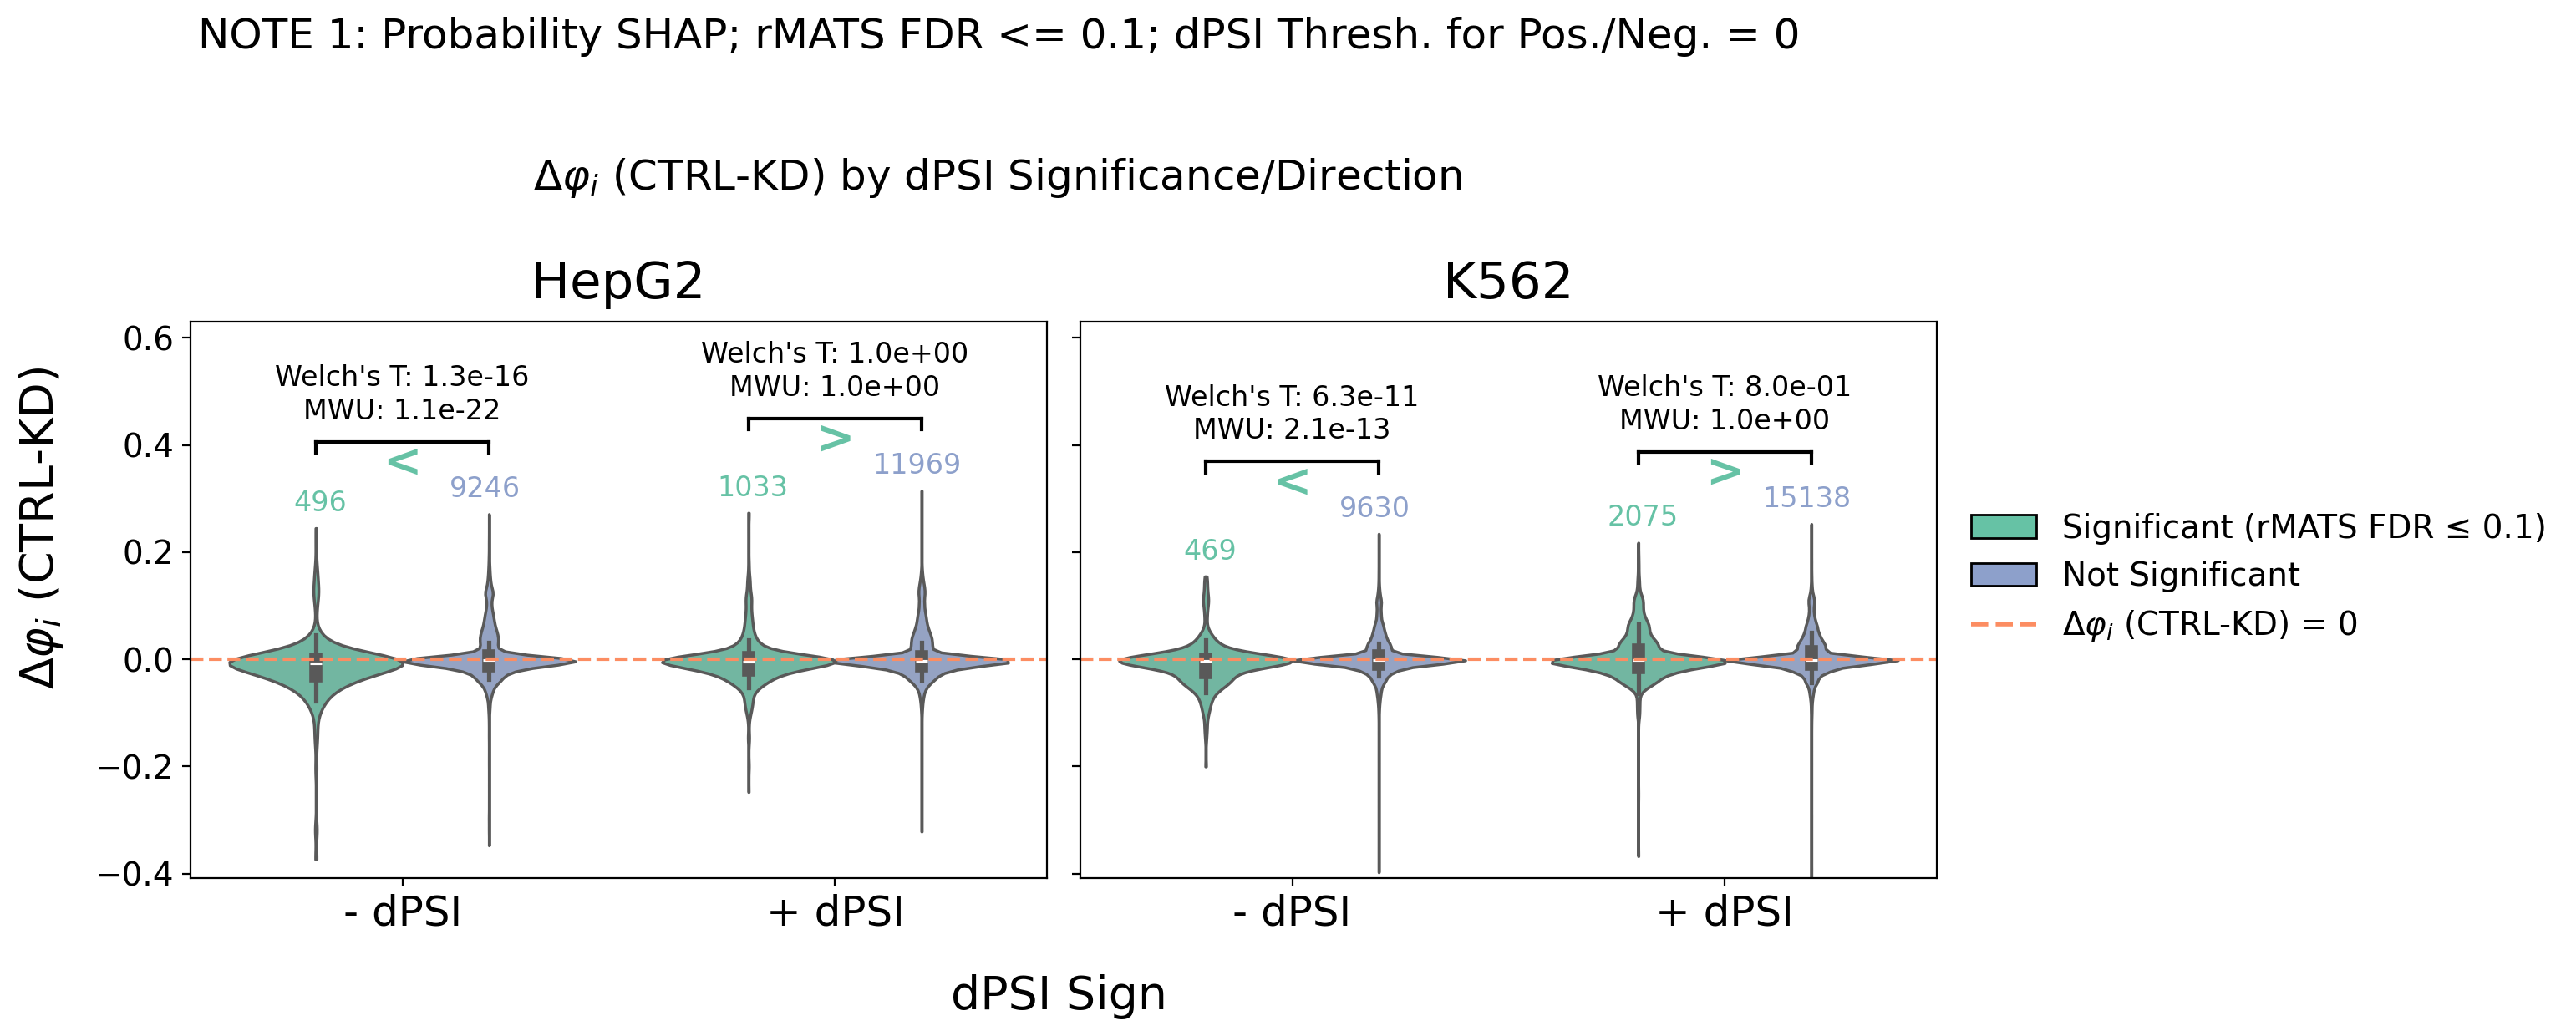

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


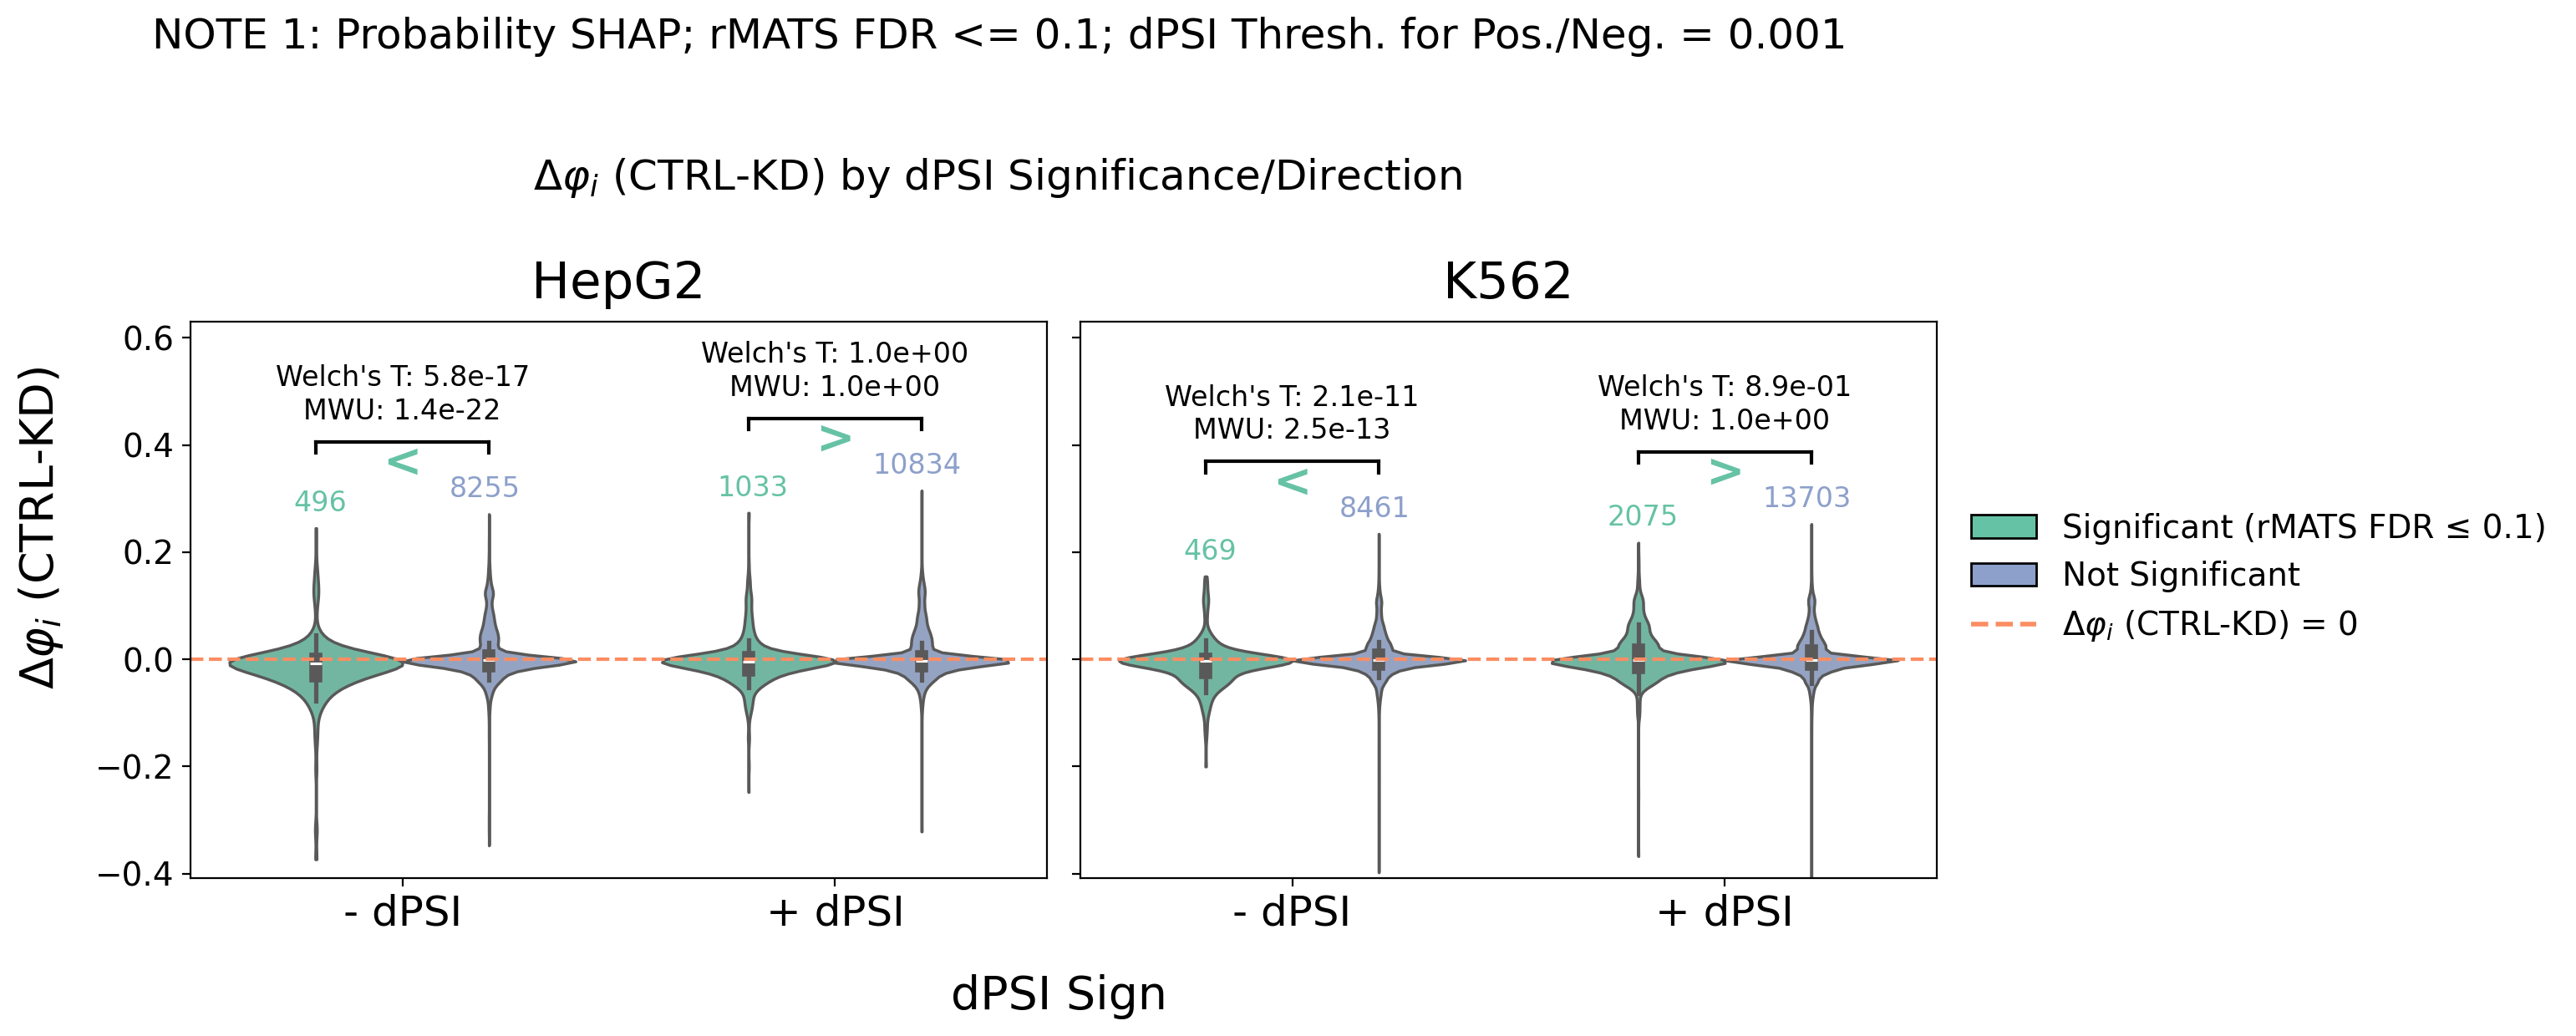

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


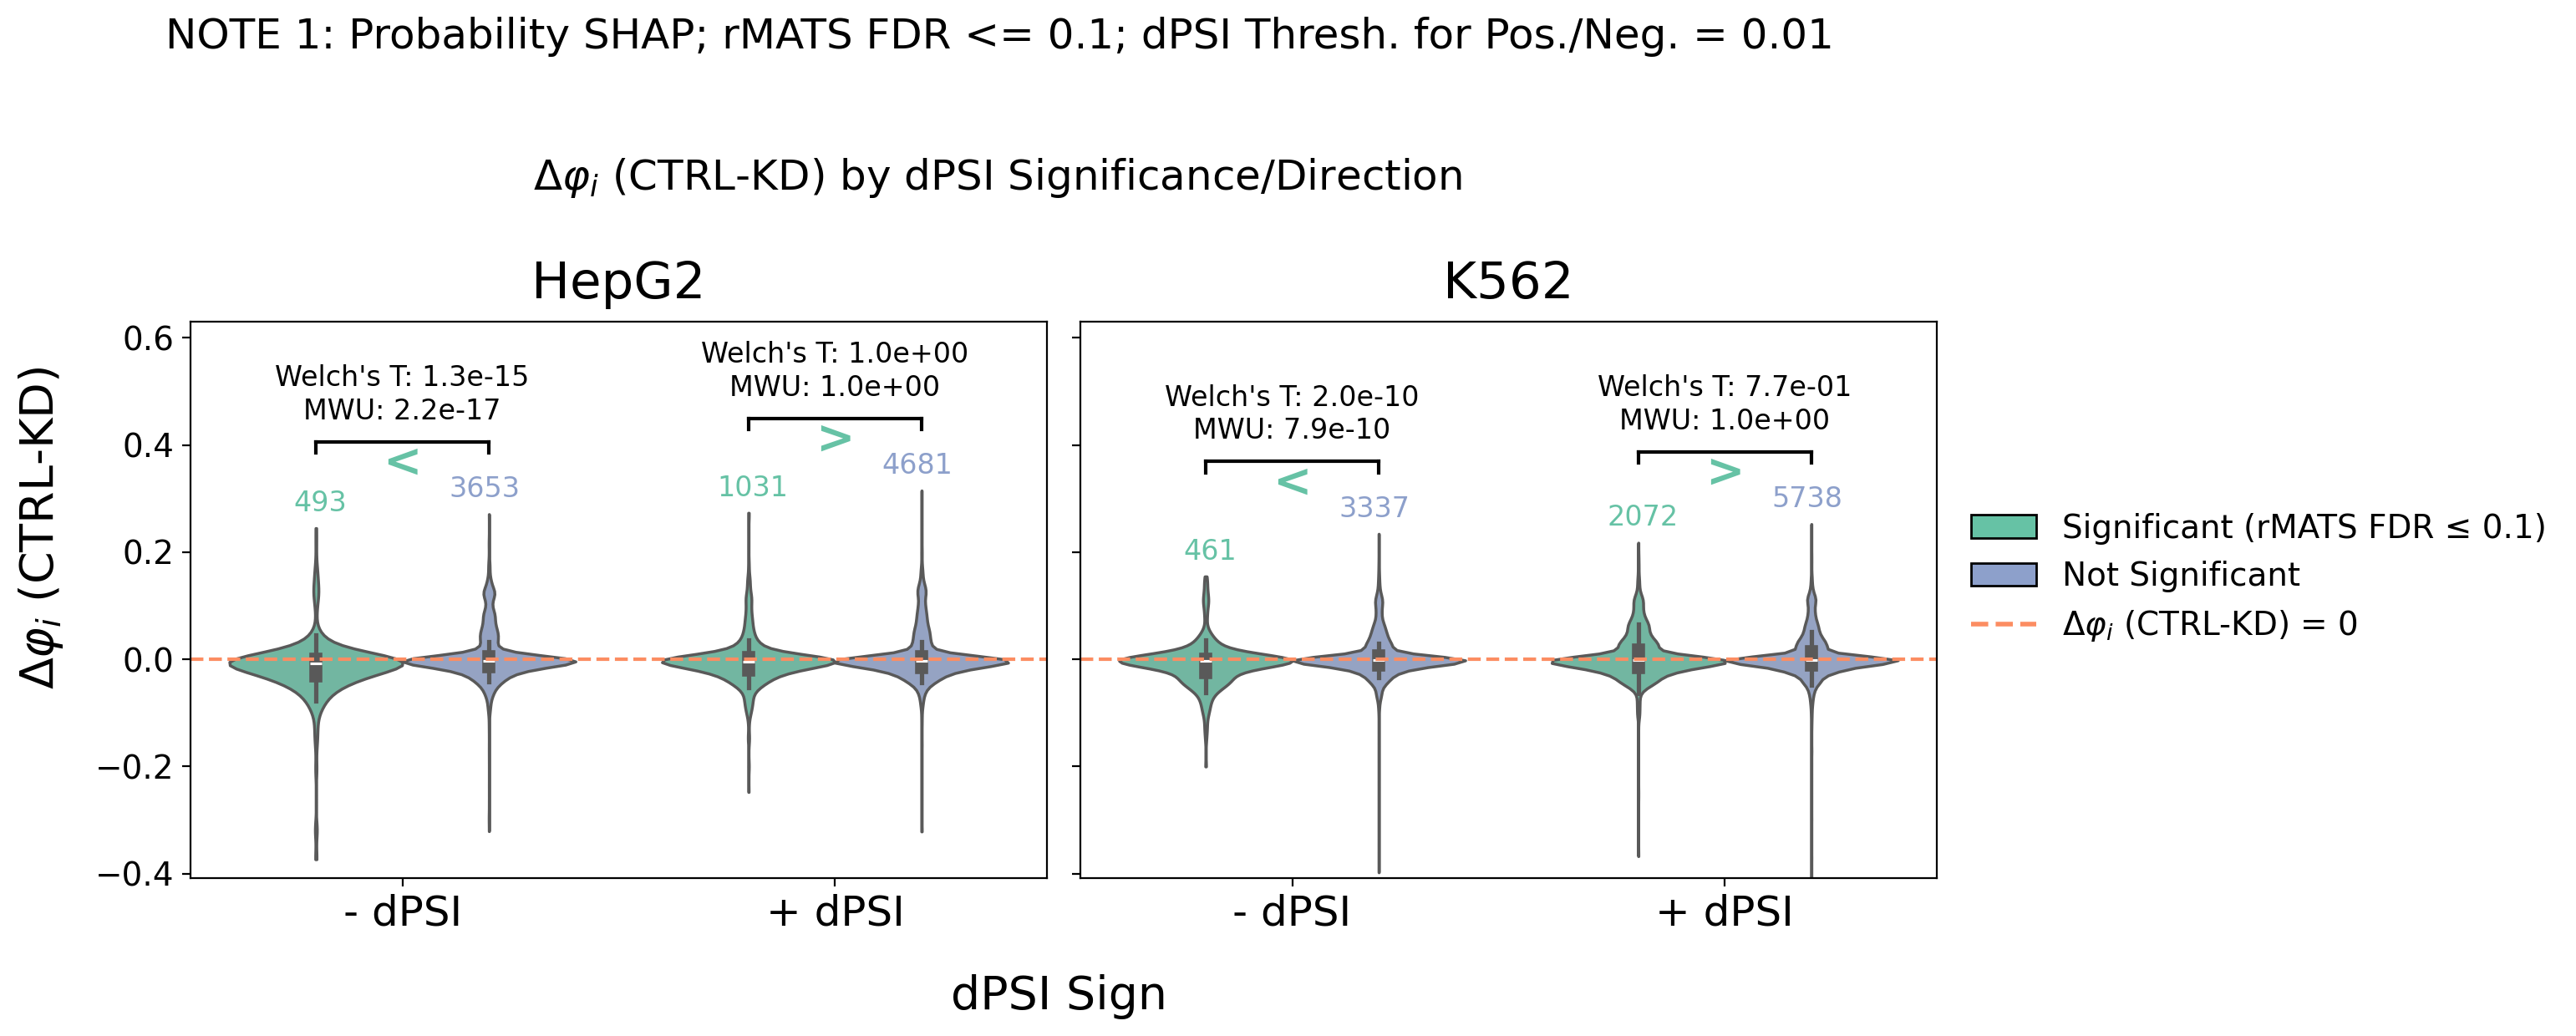

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


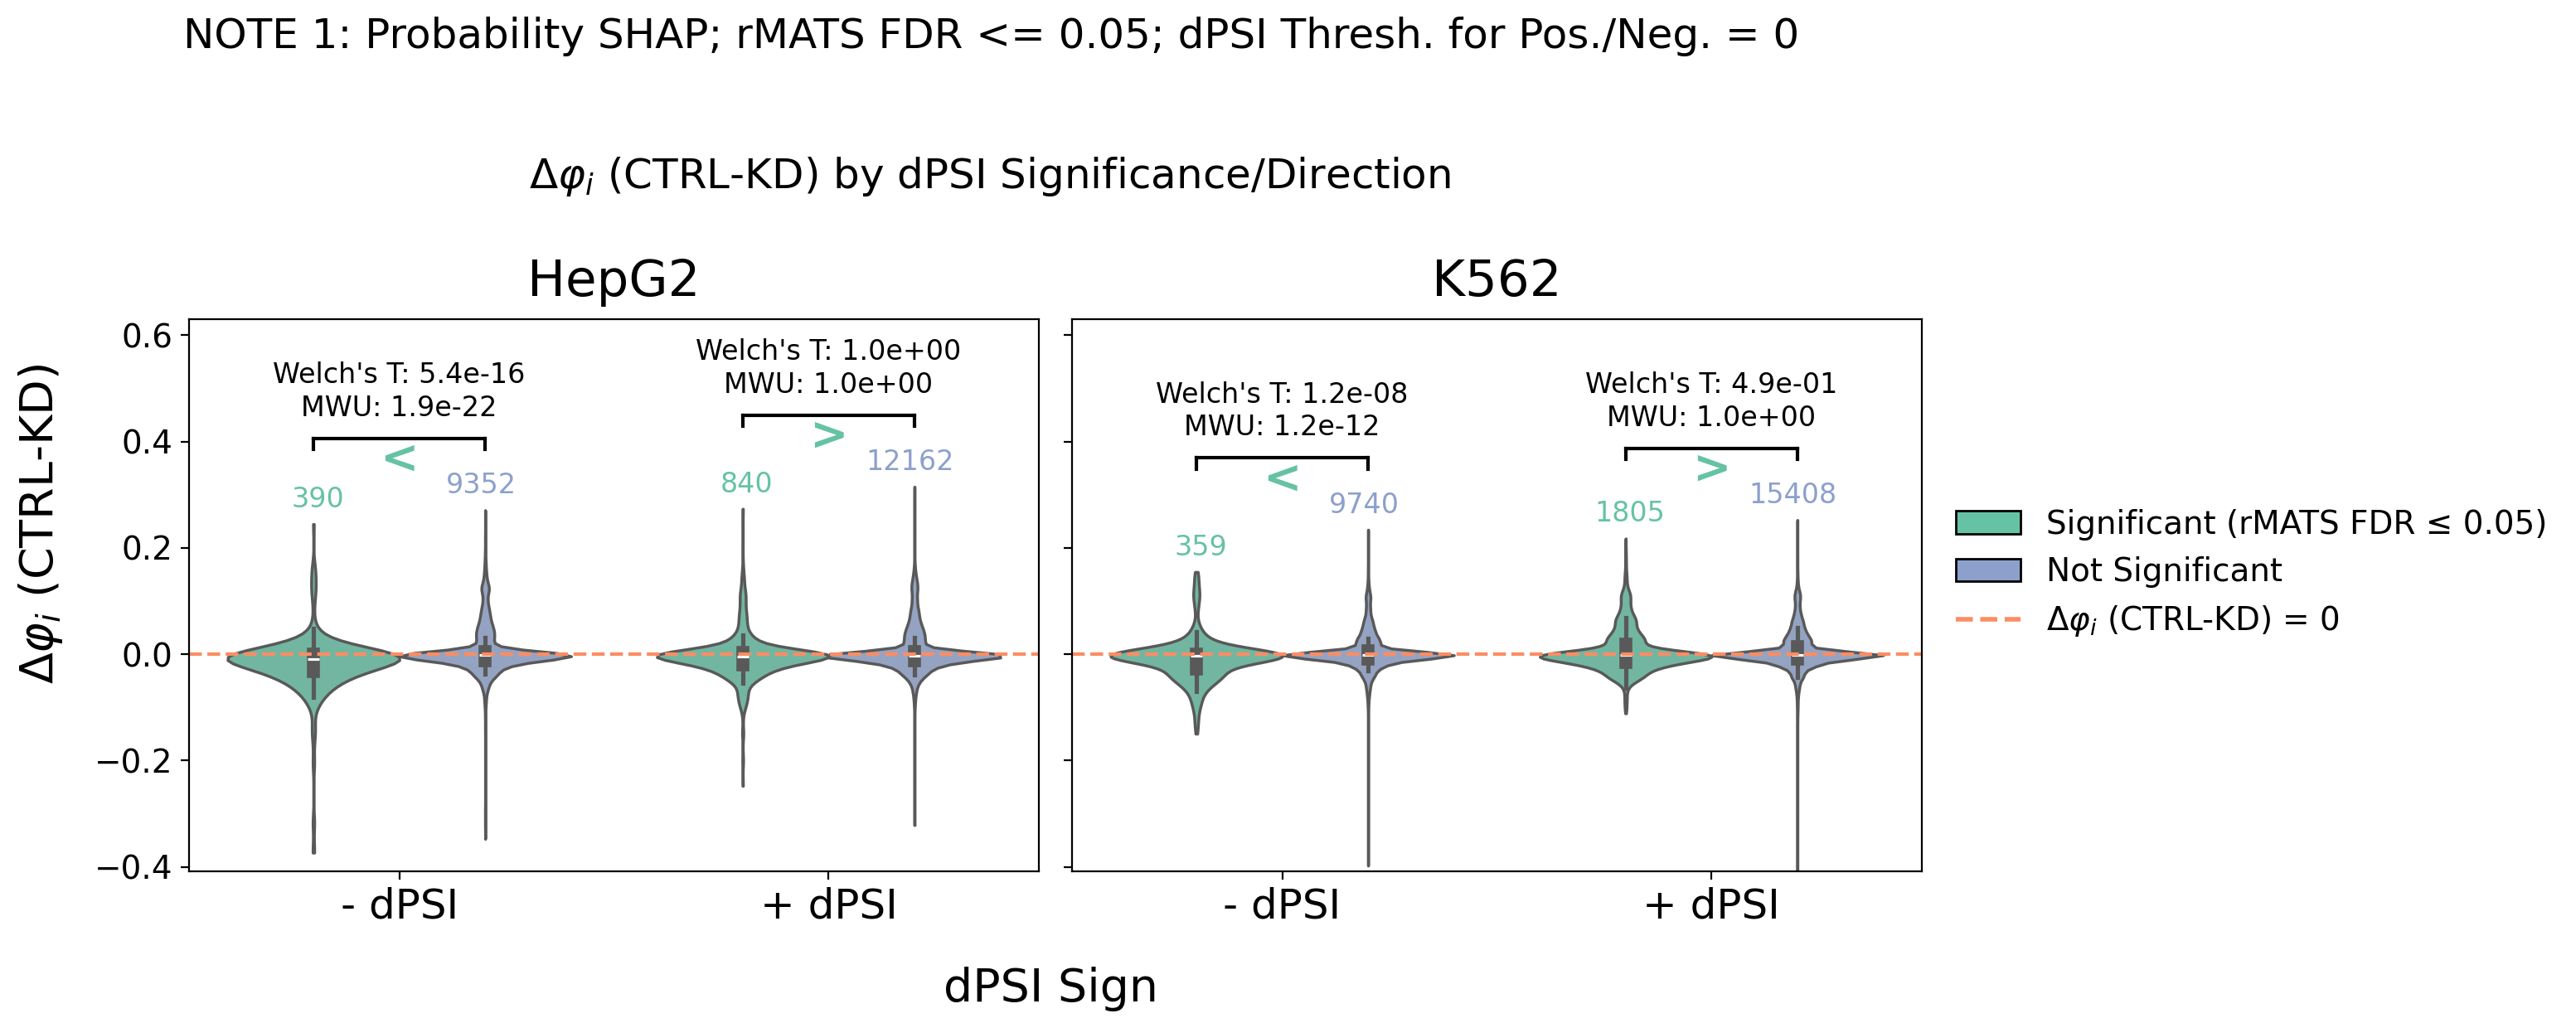

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


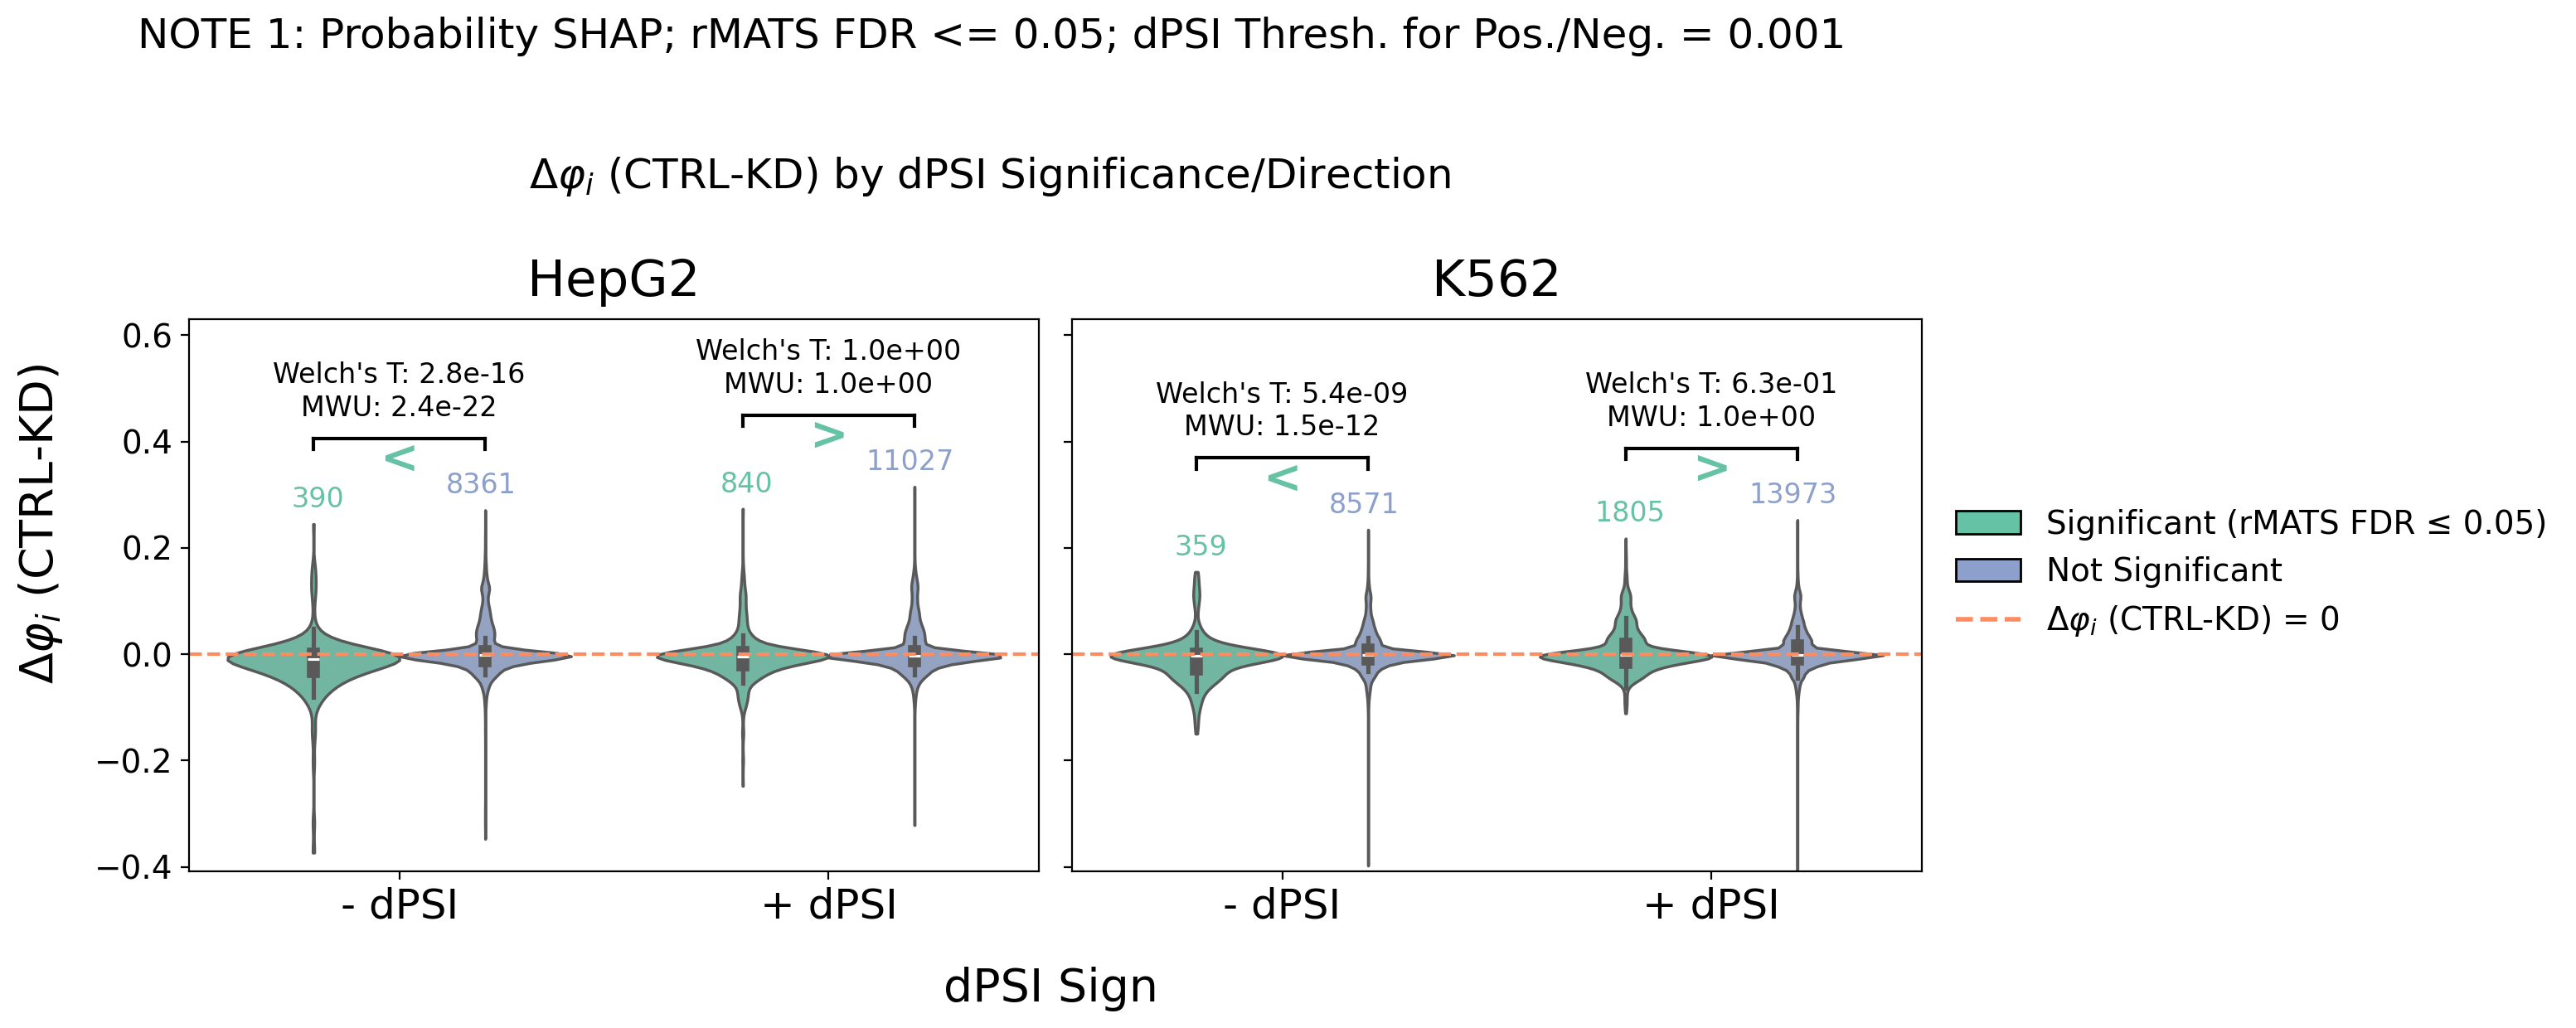

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


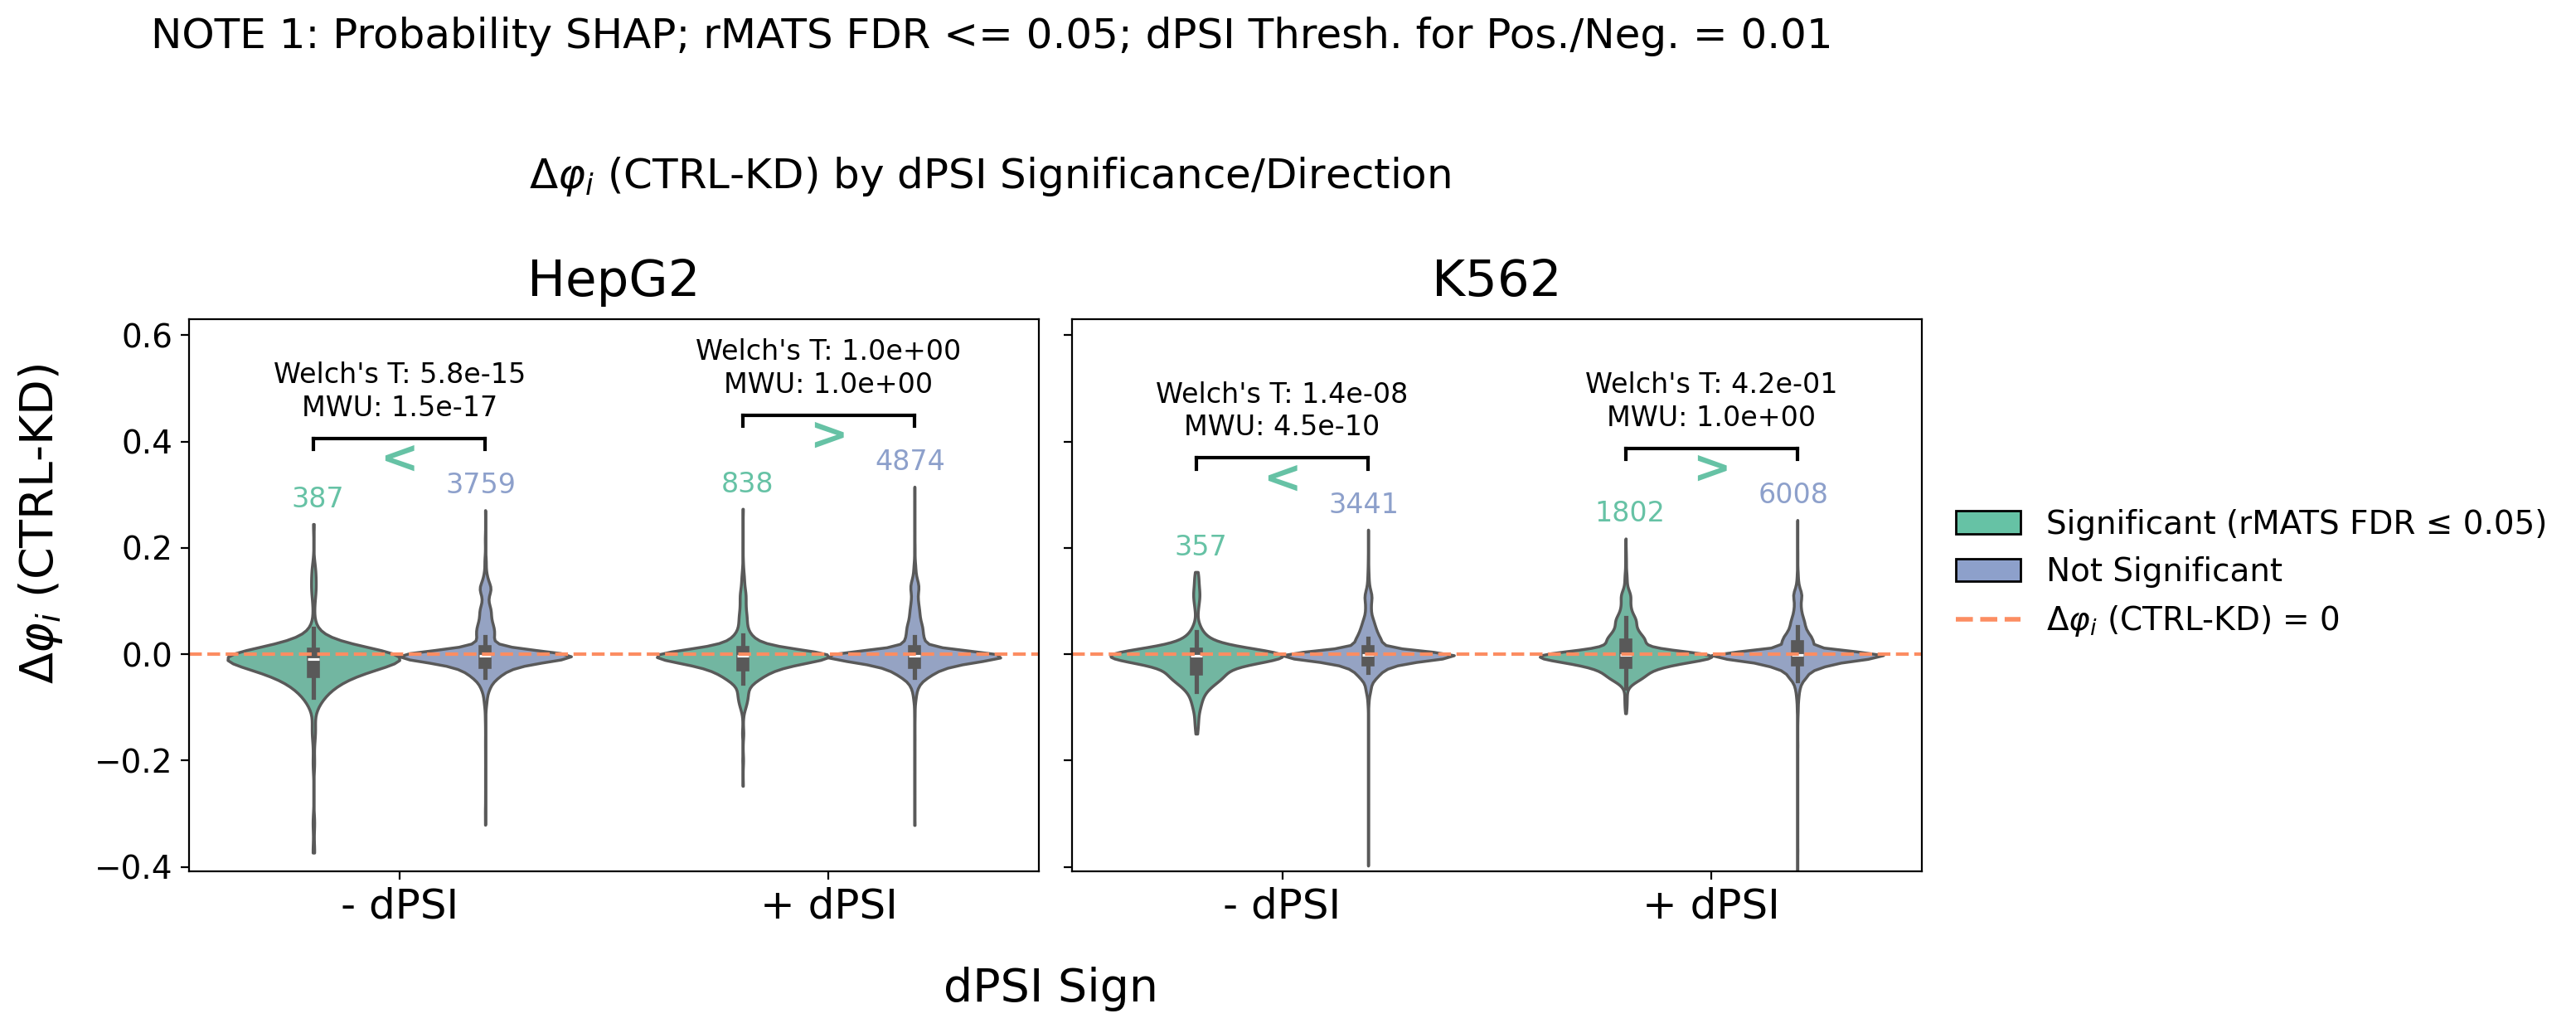

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


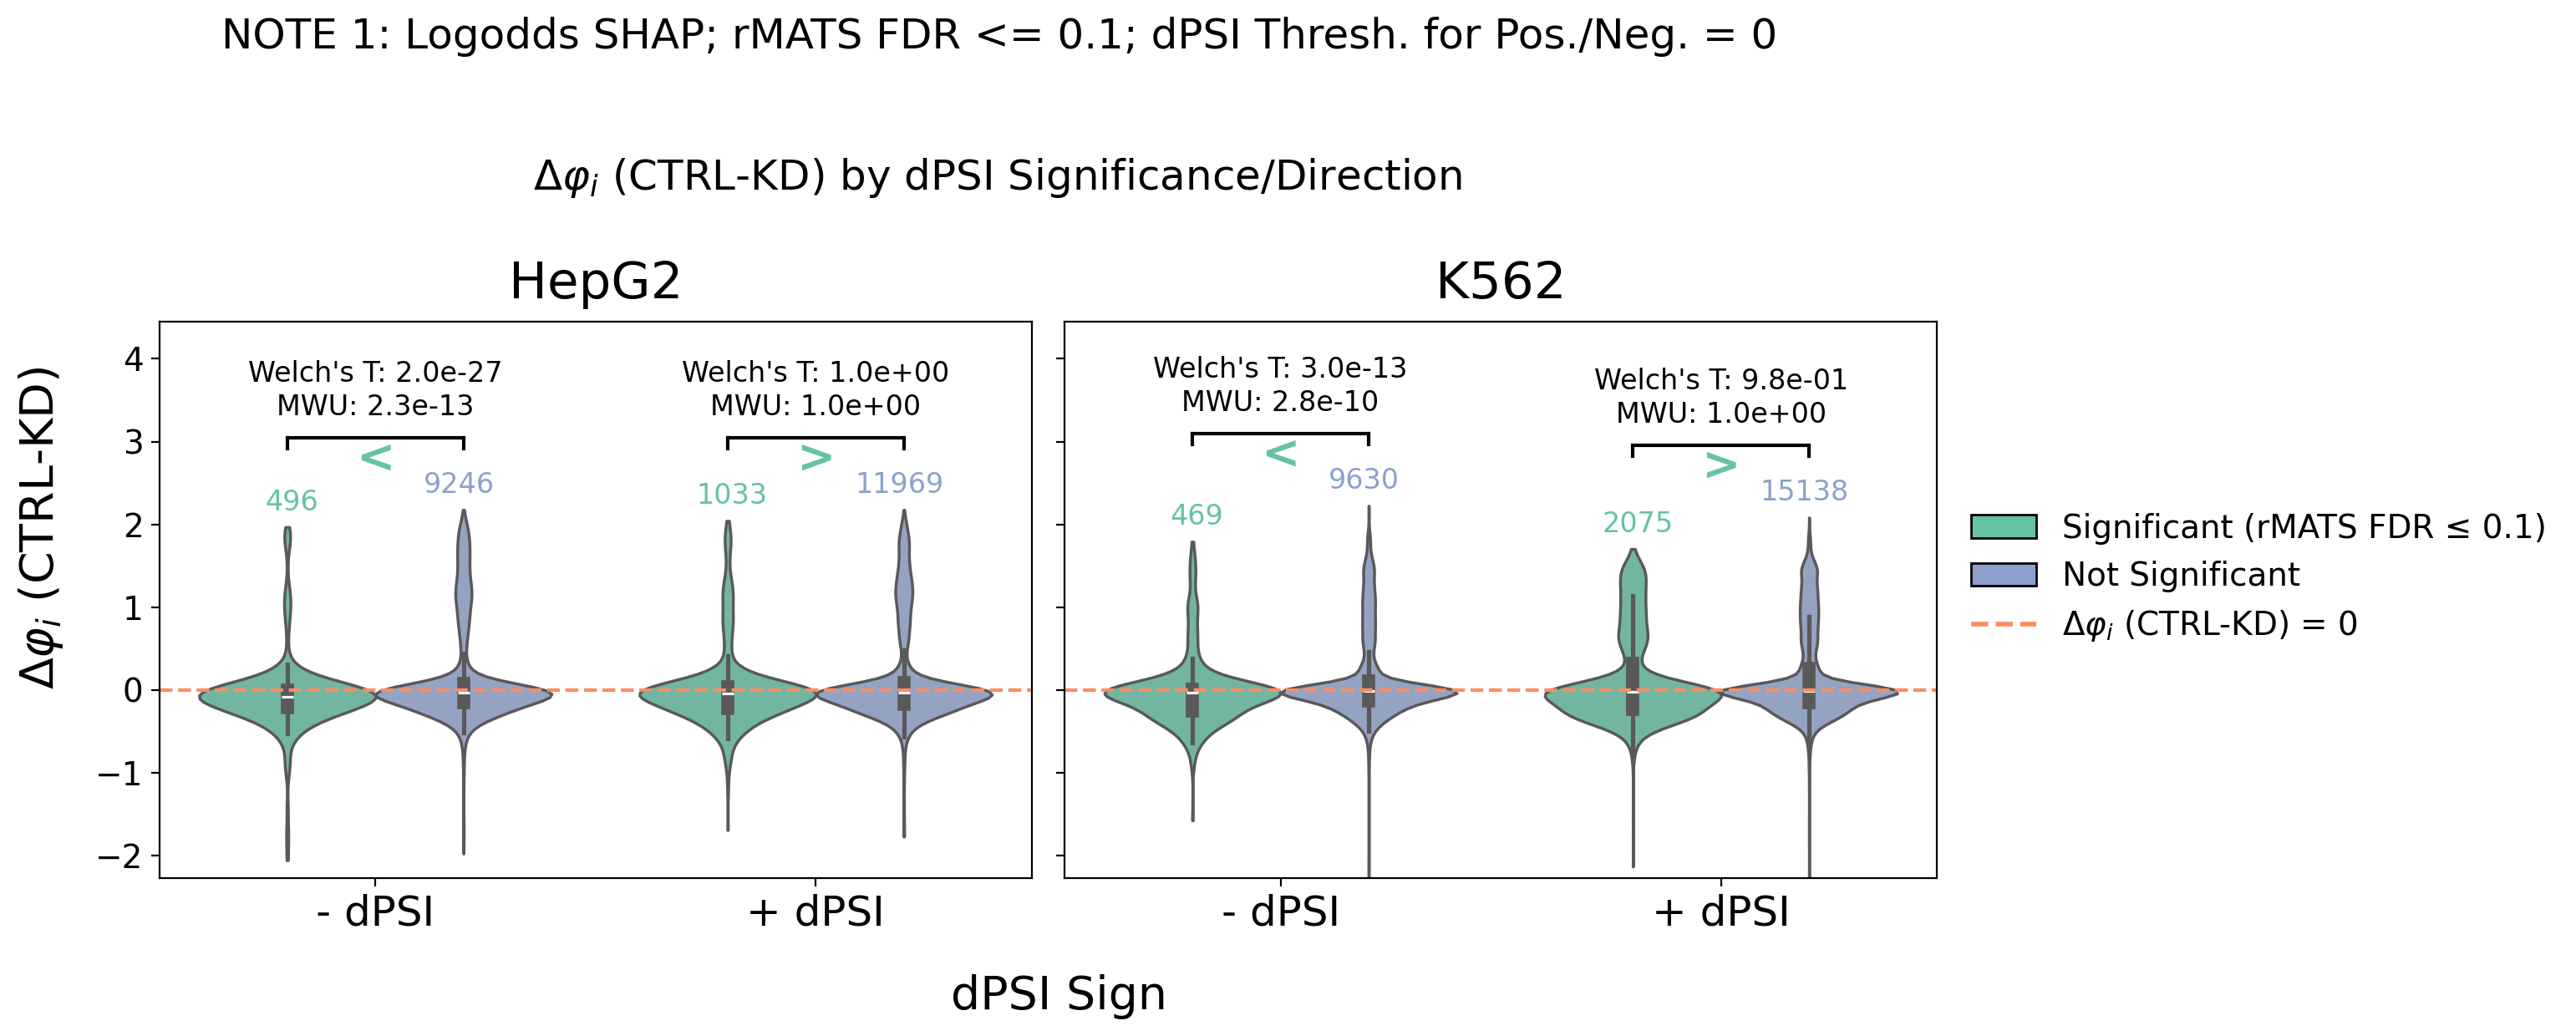

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


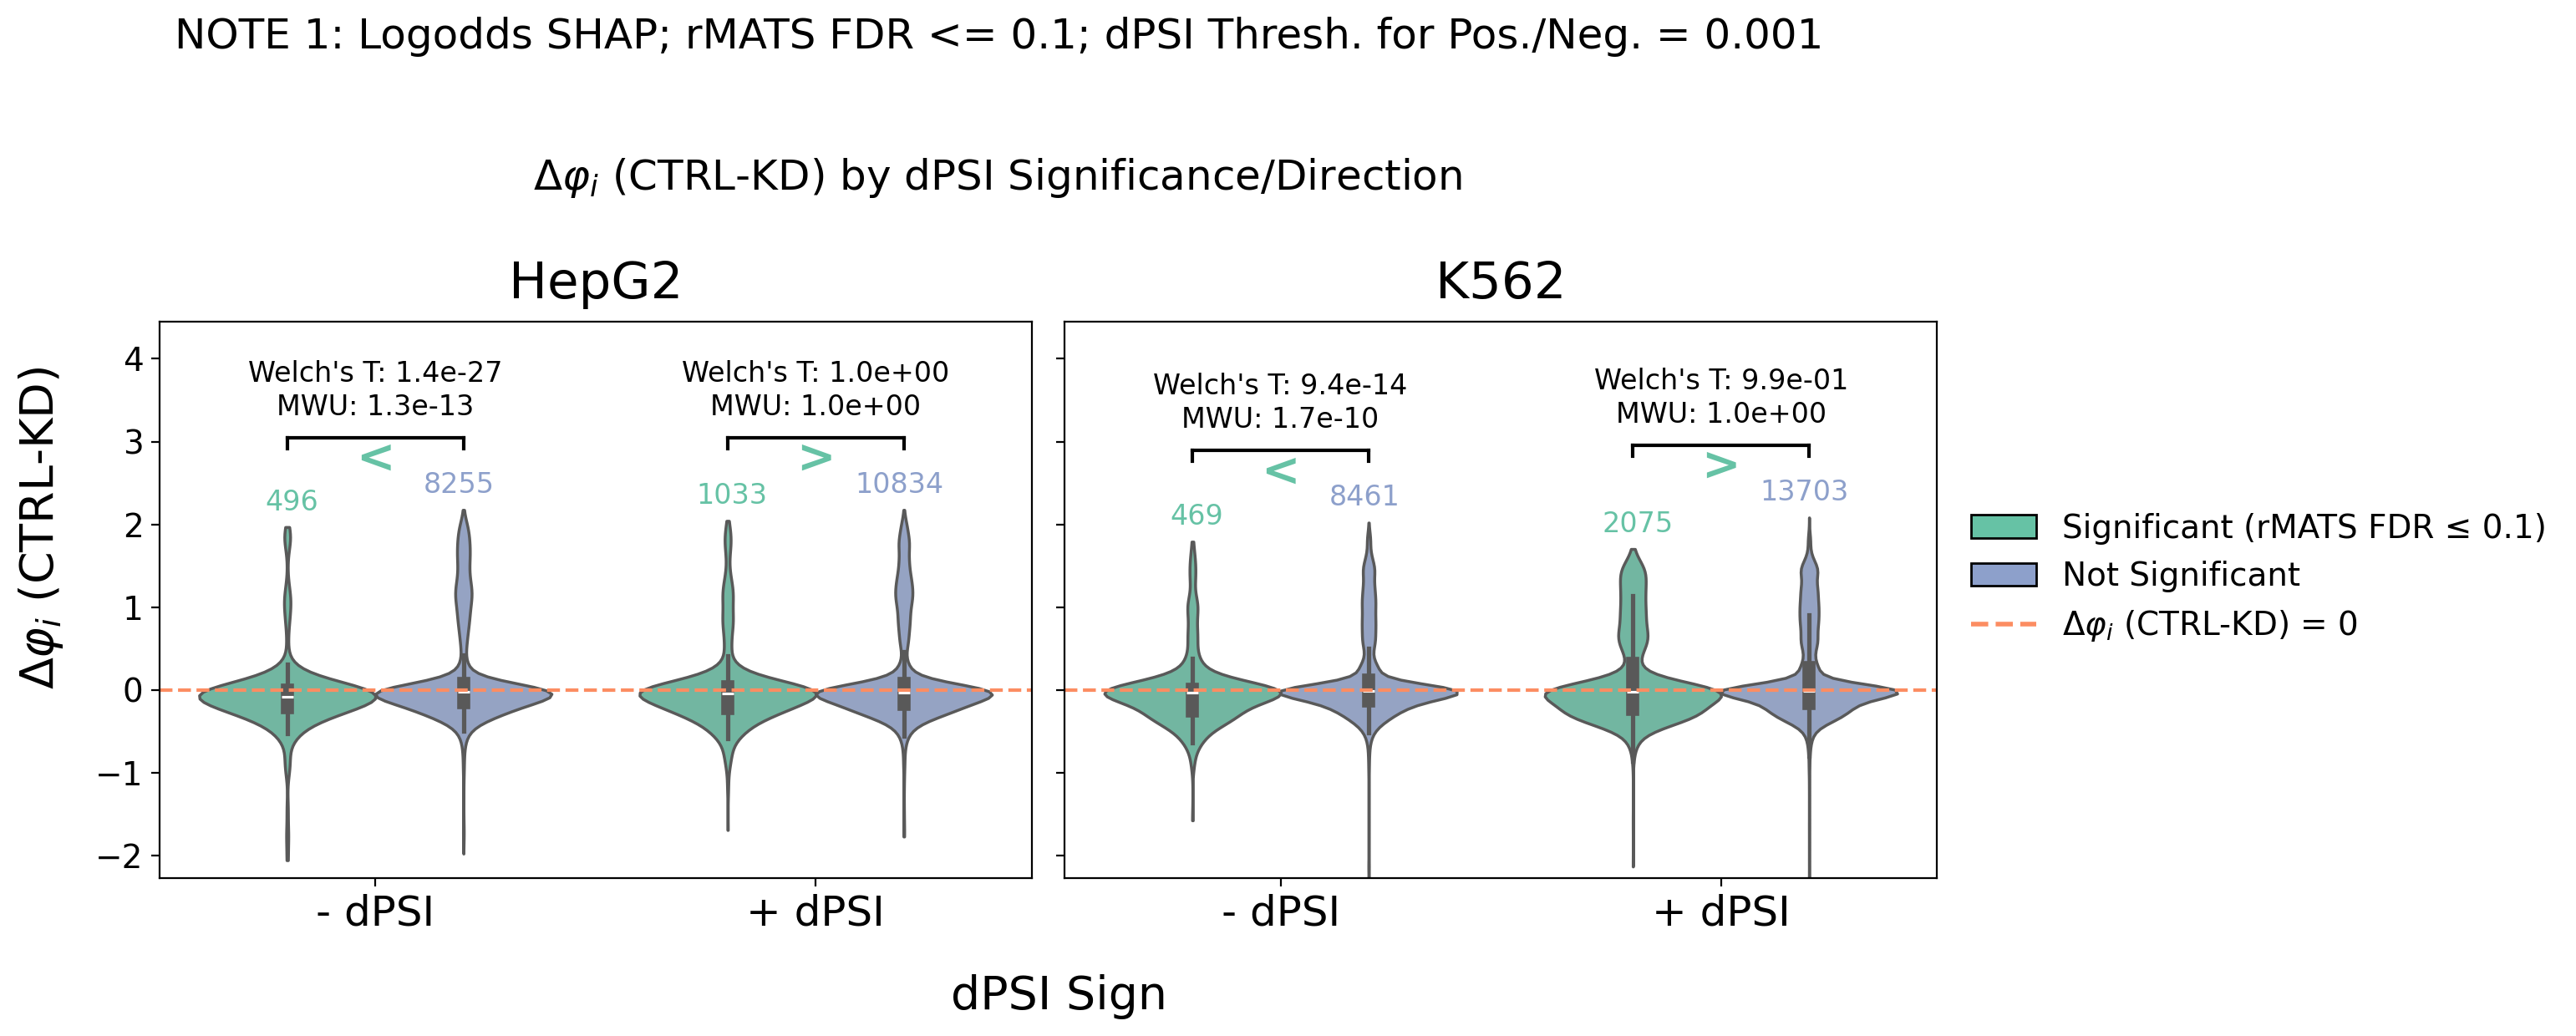

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


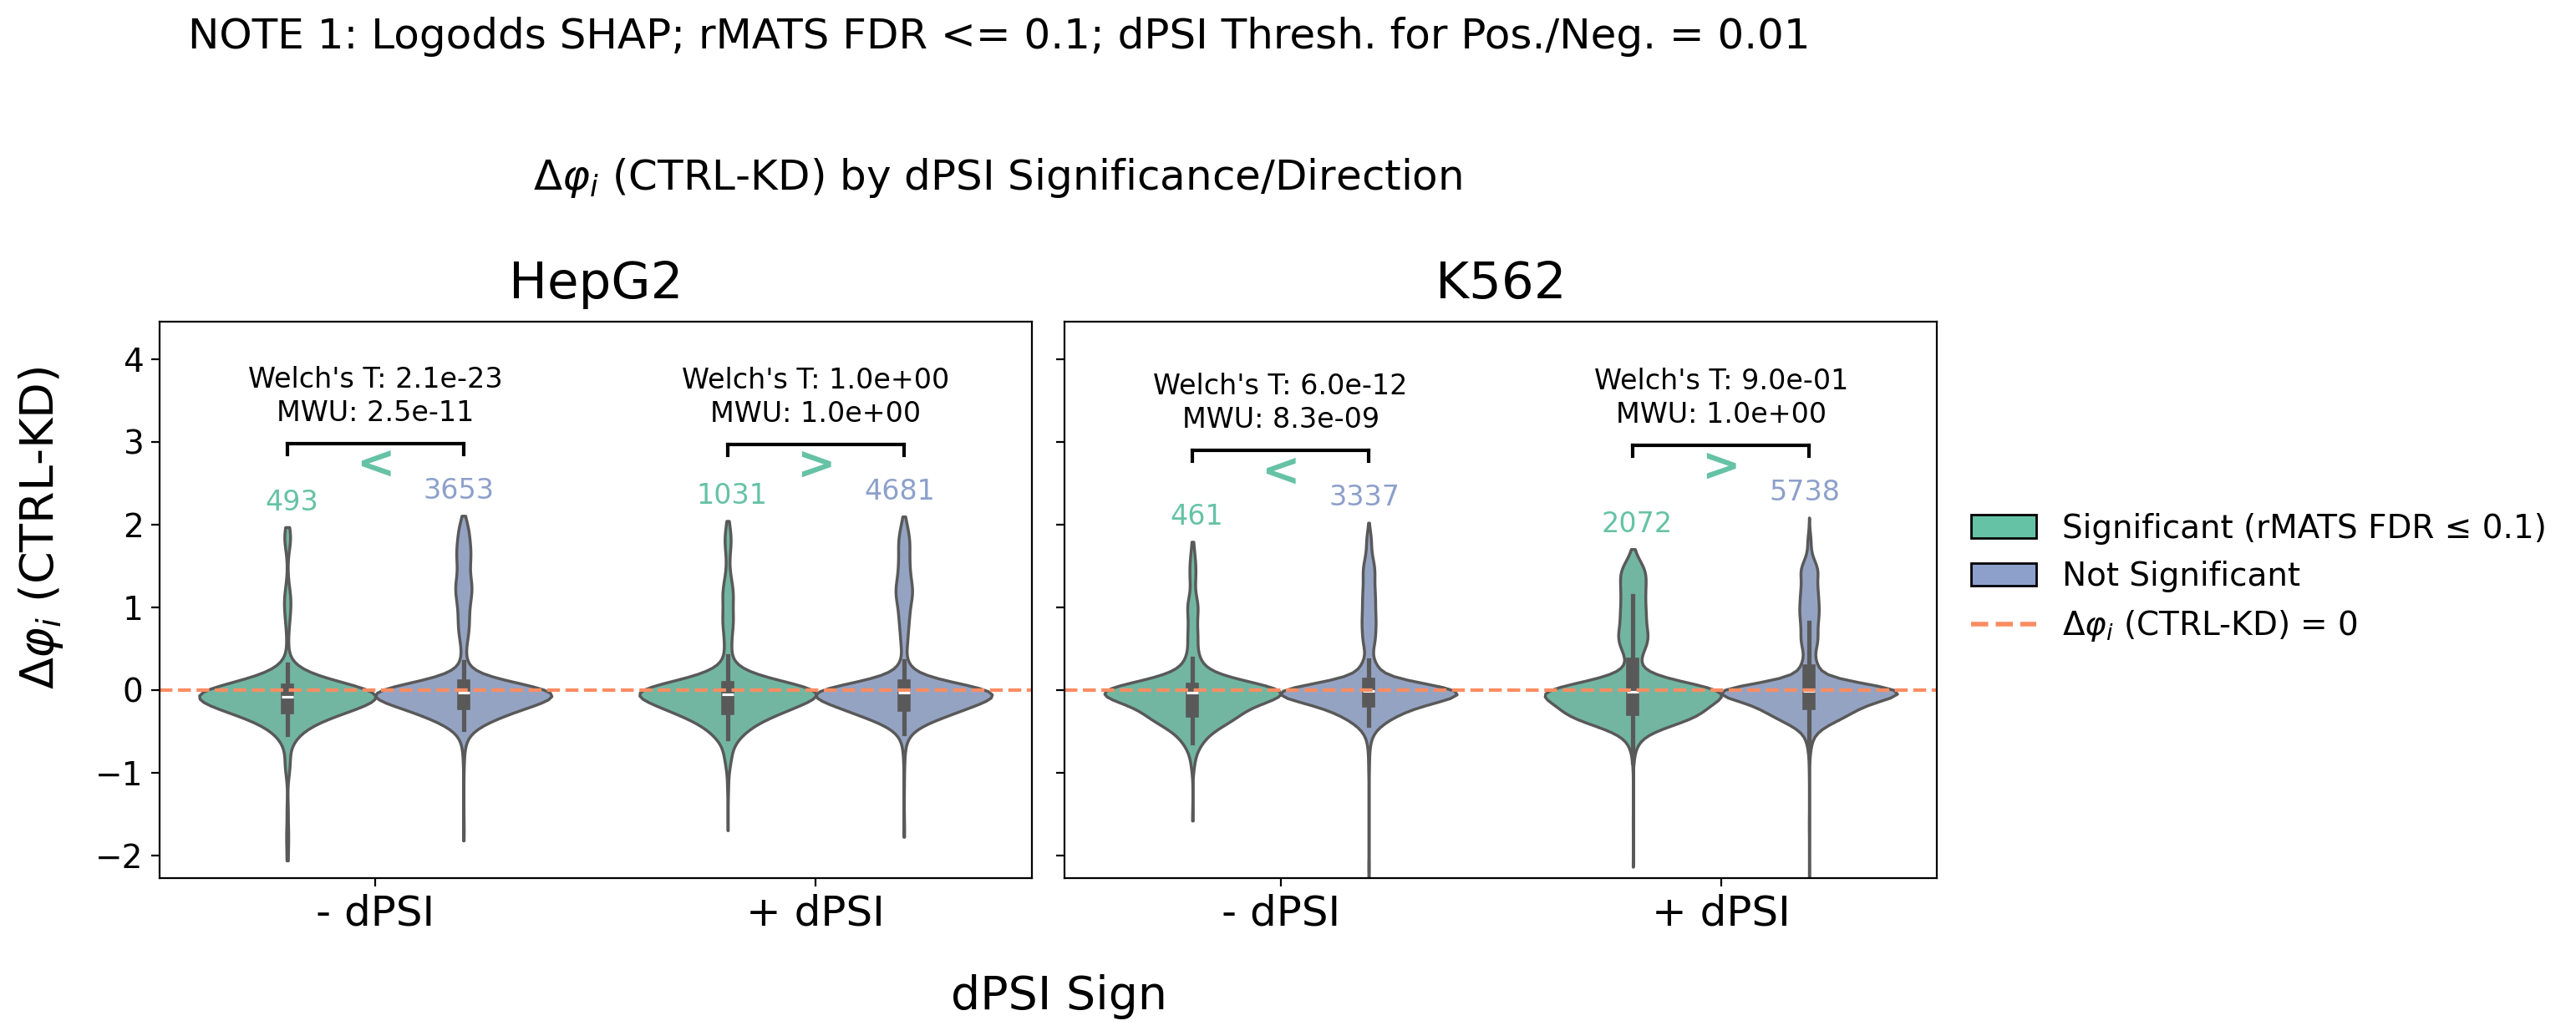

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


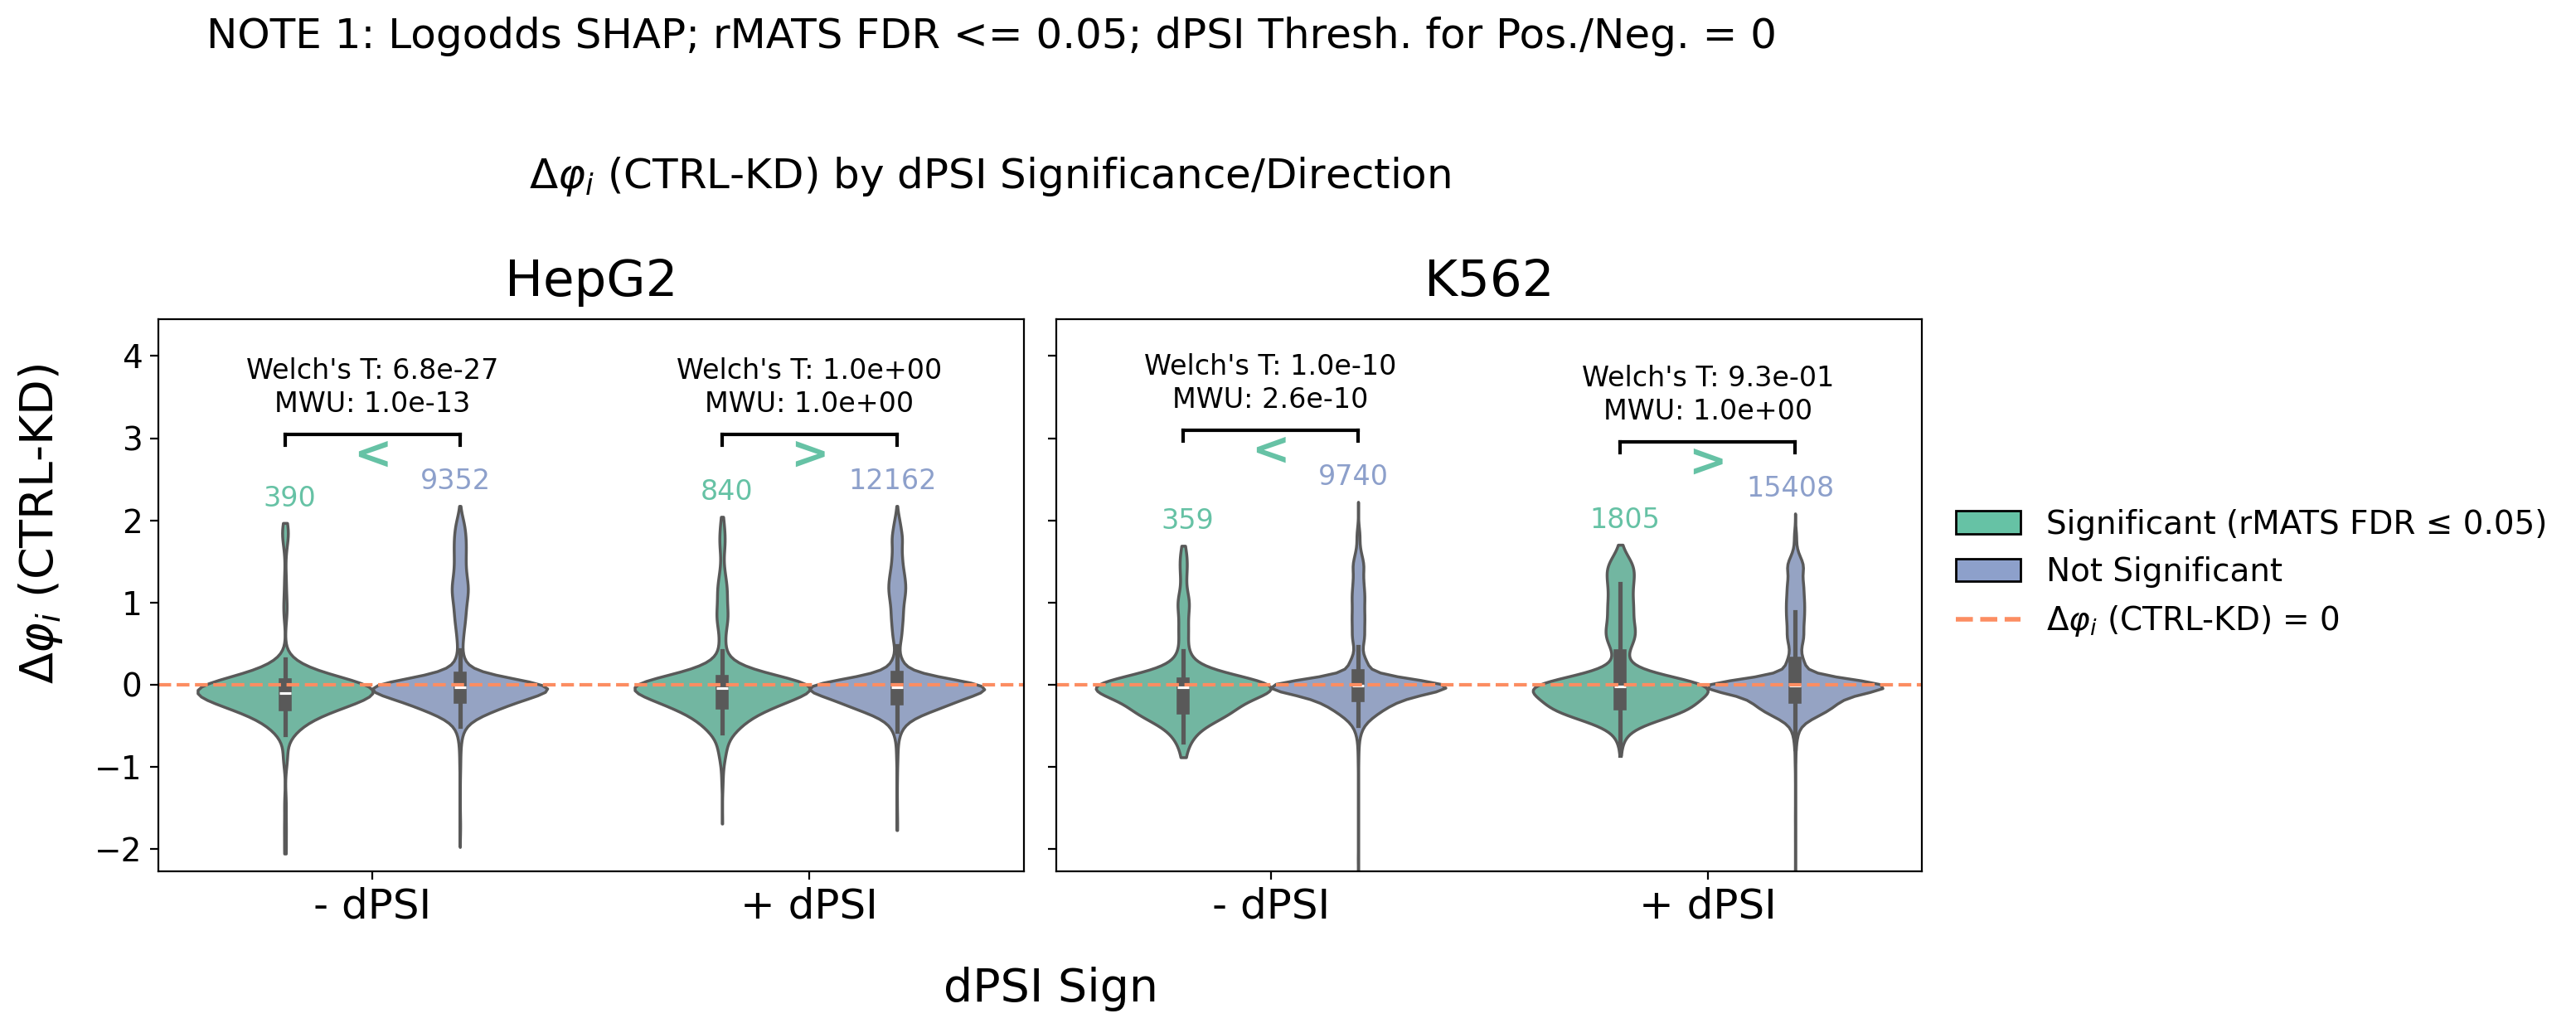

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


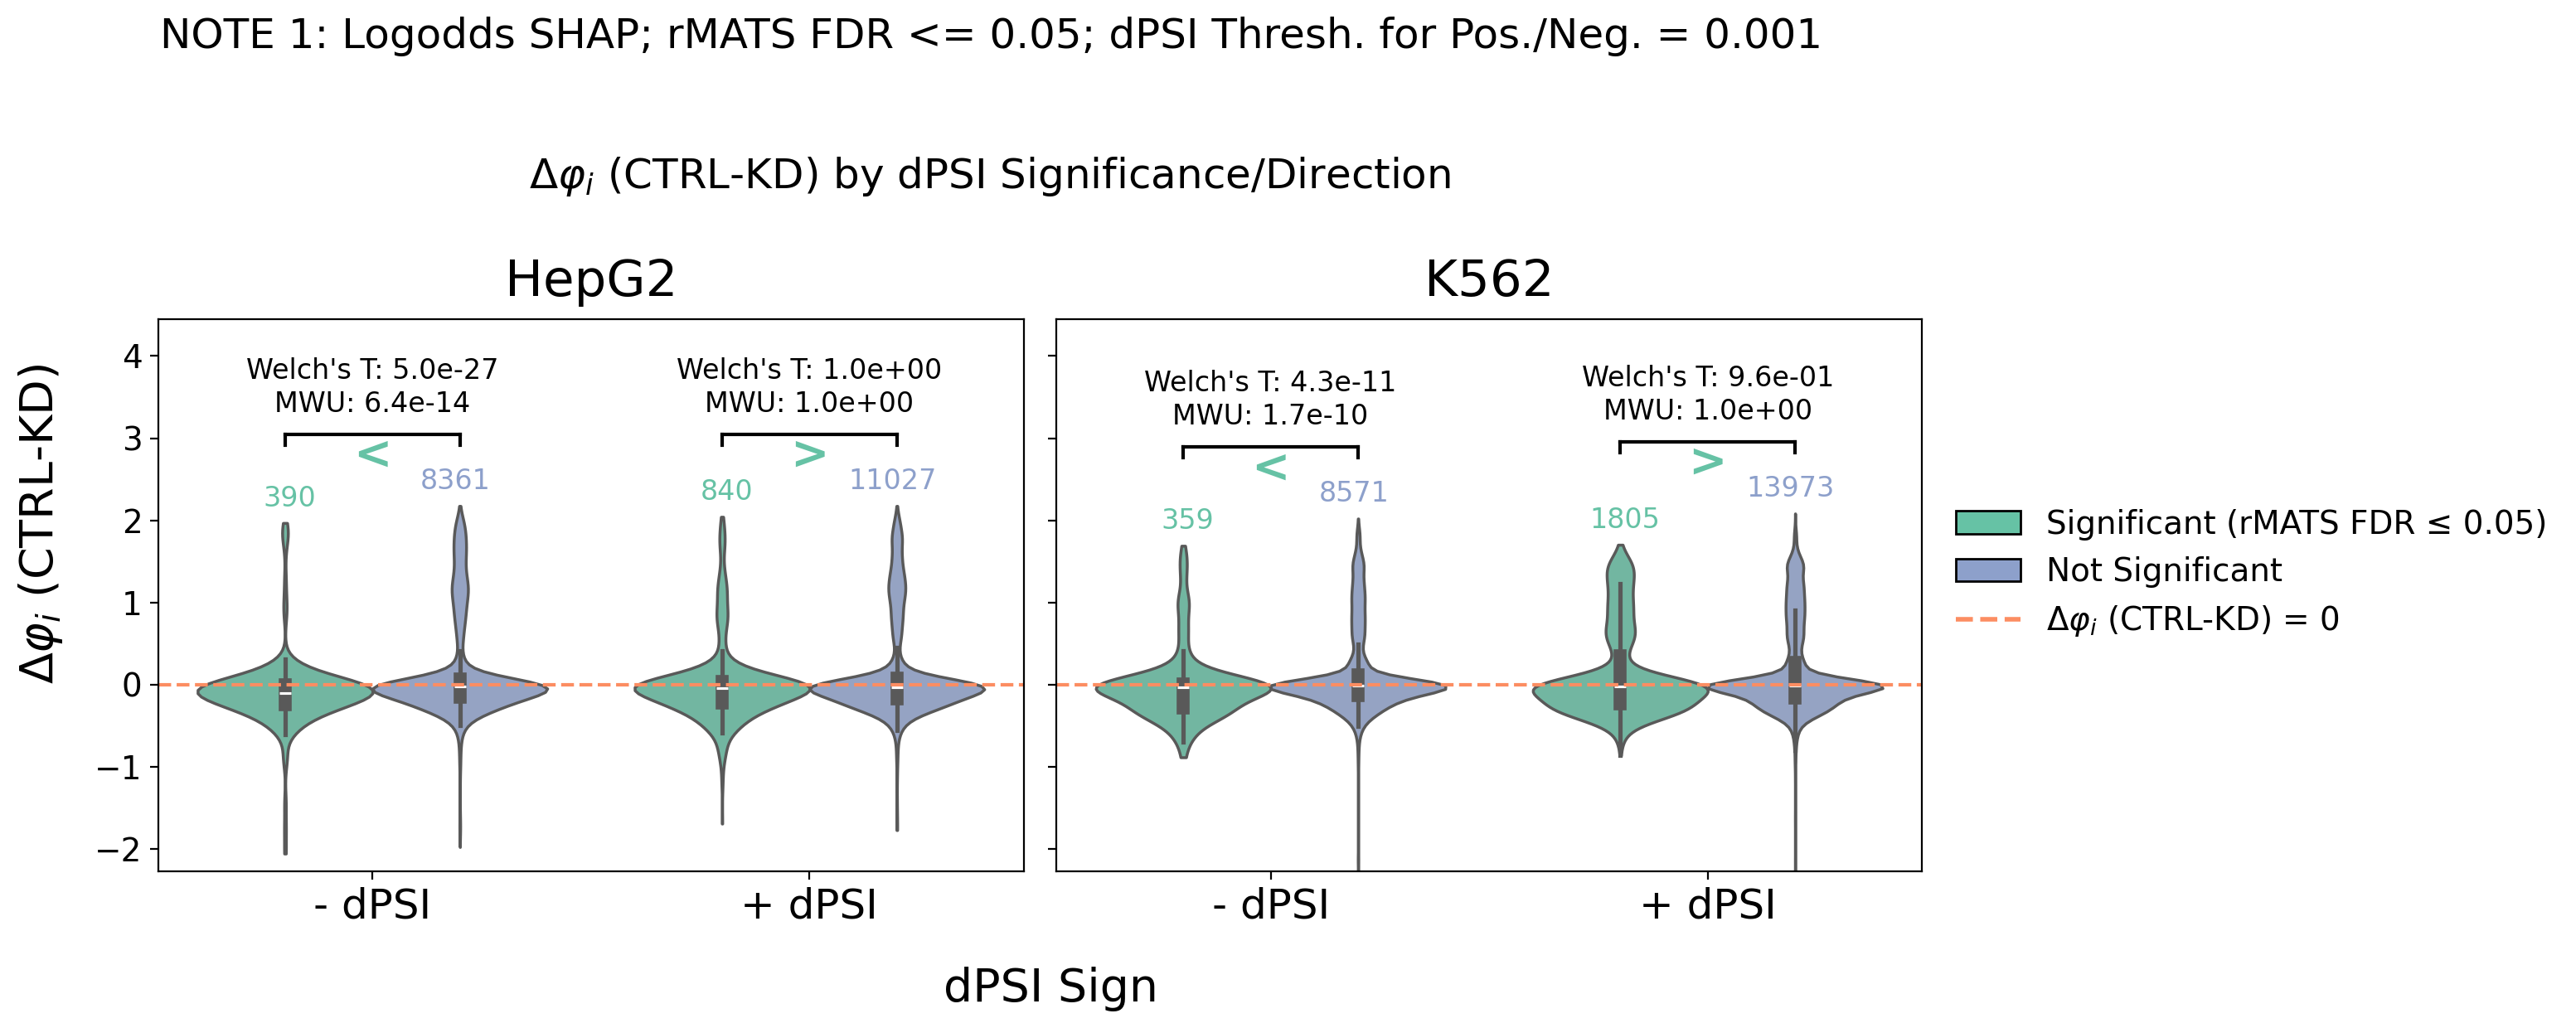

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_SHAP_network_analysis/code/1_shap_network_analyzer.py:8439: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+ dPSI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cell.loc[df_cell["dPSI"] > dpsi_threshold, "dPSI Sign"] = "+ dPSI"


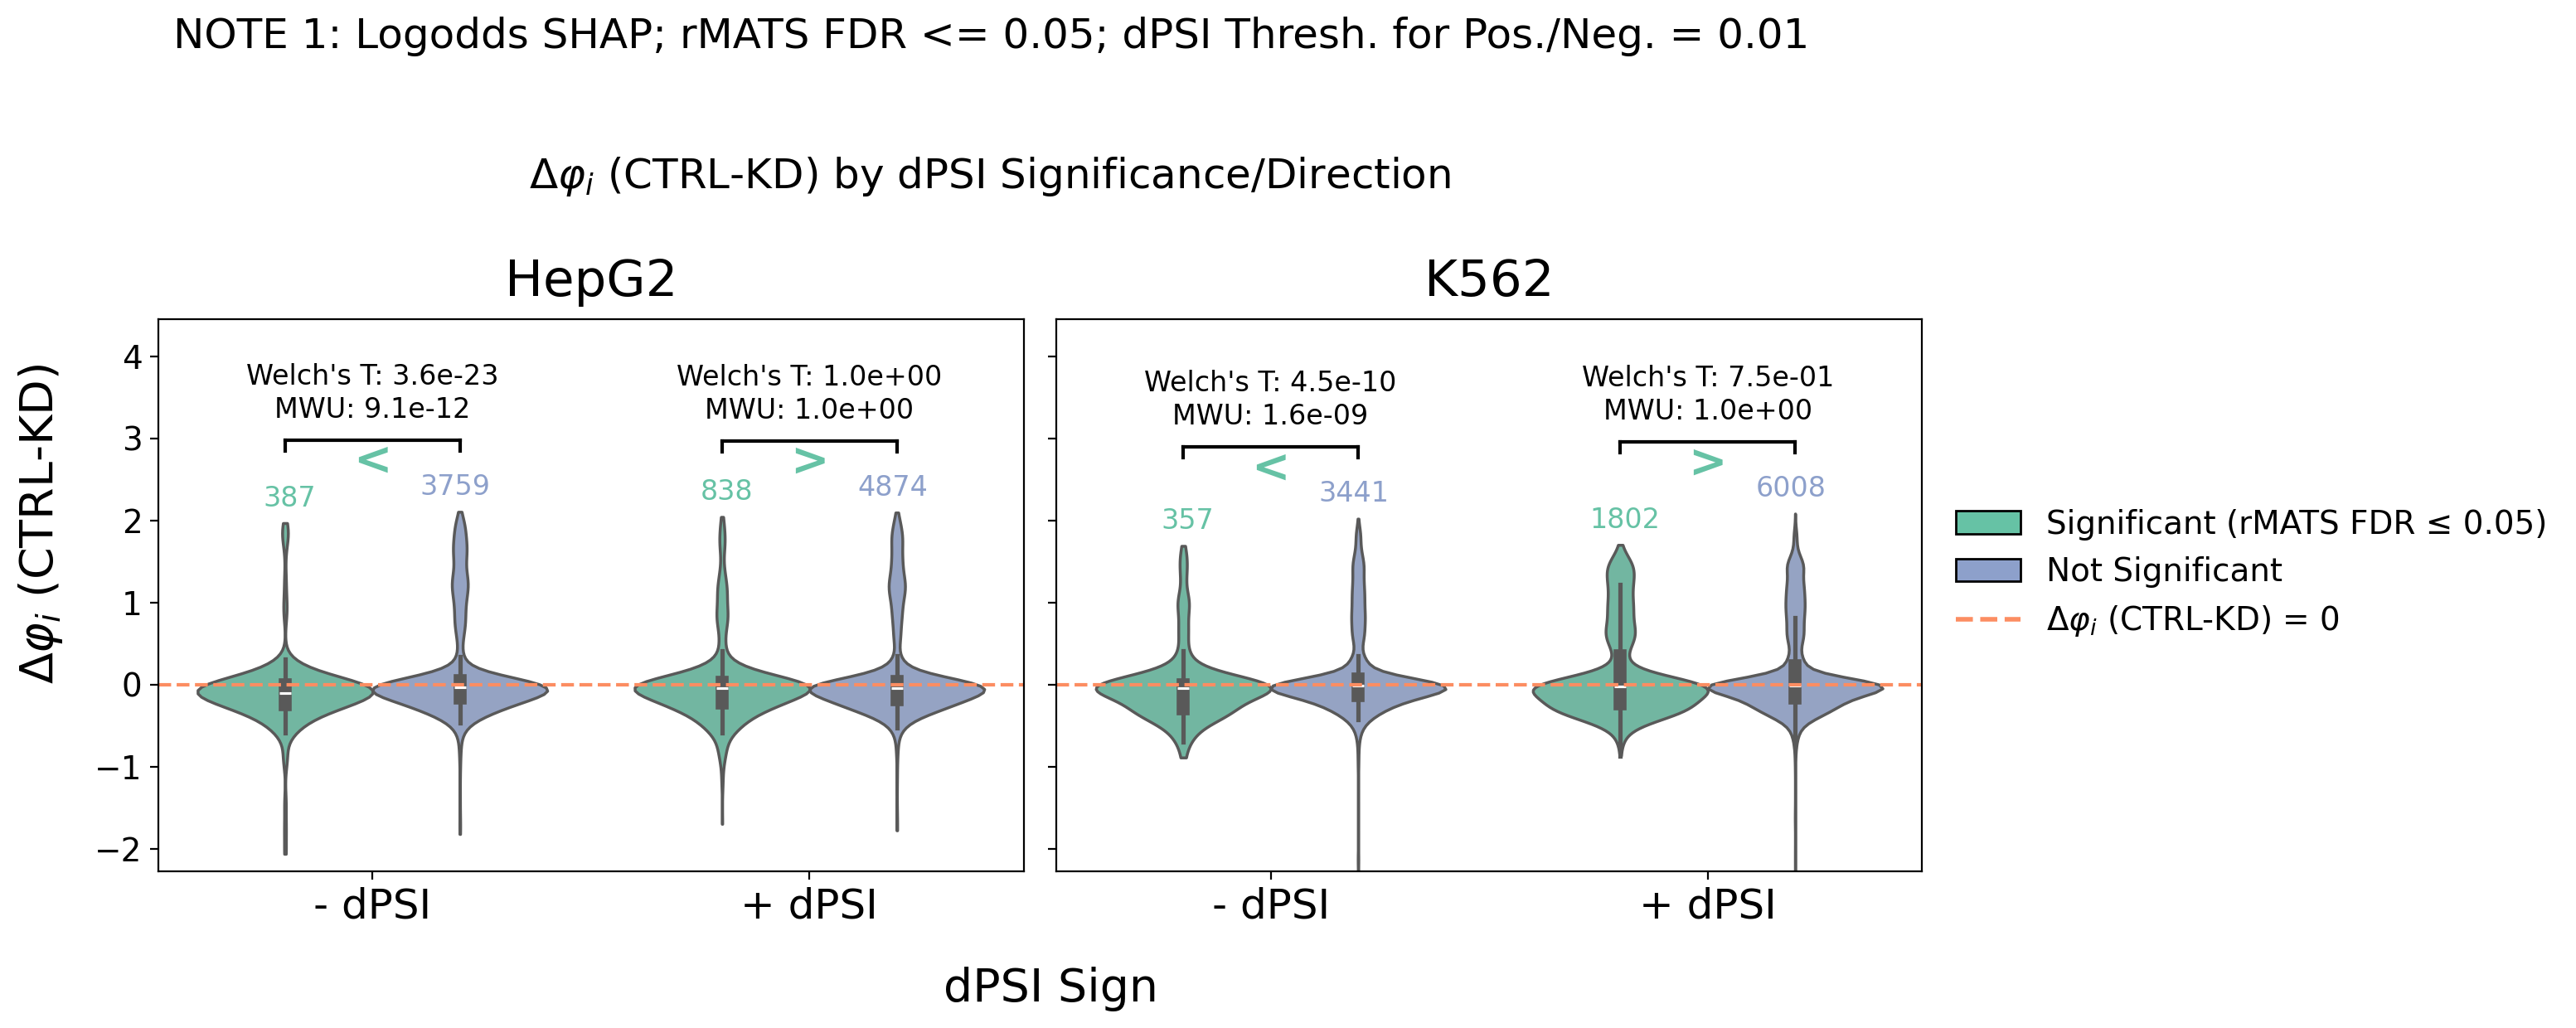

In [10]:
for only_candidate_features in [True, False]:  
    investigator.delta_local_SHAP_significant_vs_not_significant_by_pos_neg_dpsi_in_test(only_candidate_features = only_candidate_features)

In [ ]:
investigator.plot_feature_candidates_for_dpsi_vs_local_SHAP_in_test()